# RNA viromics of Southern California wastewater
### Author: Shawn Higdon
### Date: July 2, 2026

> This notebook presents a reproducible reanalysis of selected metatranscriptomic wastewater samples from Rothman et al., focusing on preprocessing, QC, host filtering, taxonomic composition, viral relative abundance, and SARS-CoV-2 signal across enriched and unenriched samples. The computational preprocessing and table generation were performed with Snakemake, while this notebook reads workflow outputs to generate figures and biological interpretations. 

In [3]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120

In [4]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
SUMMARY_DIR = PROJECT_ROOT / "results" / "summary"
TAX_DIR = PROJECT_ROOT / "results" / "taxonomy" / "merged"

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Summary dir:", SUMMARY_DIR)
print("Tax dir:", TAX_DIR)

assert SUMMARY_DIR.exists(), f"Missing summary directory: {SUMMARY_DIR}"

Notebook dir: /Users/shigdon/latch_bio/wastewater-viromics-takehome/workflow/notebooks
Project root: /Users/shigdon/latch_bio/wastewater-viromics-takehome
Summary dir: /Users/shigdon/latch_bio/wastewater-viromics-takehome/results/summary
Tax dir: /Users/shigdon/latch_bio/wastewater-viromics-takehome/results/taxonomy/merged


In [5]:
# read summary tables
meta = pd.read_csv(SUMMARY_DIR / "sample_metadata.tsv", sep="\t")
qc = pd.read_csv(SUMMARY_DIR / "qc_summary.tsv", sep="\t")
host = pd.read_csv(SUMMARY_DIR / "host_filter_summary.tsv", sep="\t")
viral = pd.read_csv(SUMMARY_DIR / "viral_taxa_summary.tsv", sep="\t")

species_path = TAX_DIR / "bracken_species_counts.tsv"
genus_path = TAX_DIR / "bracken_genus_counts.tsv"

species = pd.read_csv(species_path, sep="\t") if species_path.exists() else None
genus = pd.read_csv(genus_path, sep="\t") if genus_path.exists() else None

In [7]:
# sanity check on loaded tables
display(meta.head())
display(qc.head())
display(host.head())
display(viral.head())

print("meta:", meta.shape)
print("qc:", qc.shape)
print("host:", host.shape)
print("viral:", viral.shape)

print("species table exists:", species is not None)
print("genus table exists:", genus is not None)

,sample,site,date,treatment,is_enriched
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,True
1,HTP_2020-11-03_unenriched,HTP,2020-11-03,unenriched,False
2,HTP_2020-11-24_enriched,HTP,2020-11-24,enriched,True
3,HTP_2020-11-24_unenriched,HTP,2020-11-24,unenriched,False
4,HTP_2020-12-04_enriched,HTP,2020-12-04,enriched,True


,sample,reads_before,reads_after,reads_retained_fraction,bases_before,bases_after,bases_retained_fraction,read1_mean_length_before,read2_mean_length_before,read1_mean_length_after,...,gc_content_after,passed_filter_reads,low_quality_reads,too_many_N_reads,adapter_dimer_reads,too_short_reads,too_long_reads,duplication_rate,adapter_trimmed_reads,adapter_trimmed_bases
0,HTP_2020-11-03_enriched,2146302,2142140,0.998061,216776502,184670772,0.851895,101,101,86,...,0.488522,2142140,4110,52,0,0,0,0.178651,901556,31692100
1,HTP_2020-11-03_unenriched,23069046,23021664,0.997946,2329973646,1973424678,0.846973,101,101,85,...,0.491163,23021664,45368,2014,0,0,0,0.379375,9683904,351862258
2,HTP_2020-11-24_enriched,2958648,2953142,0.998139,298823448,254600738,0.852011,101,101,86,...,0.480171,2953142,5416,90,0,0,0,0.201971,1248094,43679242
3,HTP_2020-11-24_unenriched,22091754,22046204,0.997938,2231267154,1875716082,0.840651,101,101,85,...,0.484783,22046204,43556,1994,0,0,0,0.378842,9663696,351056658
4,HTP_2020-12-04_enriched,2529648,2524470,0.997953,255494448,217033802,0.849466,101,101,85,...,0.497717,2524470,5096,82,0,0,0,0.218541,1094616,37944932


,sample,bam,total_reads,mapped_reads,unmapped_reads,both_mates_unmapped,mapped_fraction,unmapped_fraction,both_mates_unmapped_fraction
0,HTP_2020-11-03_enriched,results/host_filter/bwa/HTP_2020-11-03_enriche...,115592,39406,76186,76022,0.340906,0.659094,0.657675
1,HTP_2020-11-03_unenriched,results/host_filter/bwa/HTP_2020-11-03_unenric...,114734,35020,79714,79572,0.305228,0.694772,0.693535
2,HTP_2020-11-24_enriched,results/host_filter/bwa/HTP_2020-11-24_enriche...,115580,40758,74822,74694,0.352639,0.647361,0.646254
3,HTP_2020-11-24_unenriched,results/host_filter/bwa/HTP_2020-11-24_unenric...,115669,37749,77920,77796,0.326354,0.673646,0.672574
4,HTP_2020-12-04_enriched,results/host_filter/bwa/HTP_2020-12-04_enriche...,115049,40190,74859,74718,0.349329,0.650671,0.649445


,sample,site,date,treatment,taxonomy_lvl,taxonomy_id,name,reads,viral_total_reads,relative_abundance,is_viral,is_sars_cov_2
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432872,Tobamovirus fructirugosum,4742.0,10136.0,0.467837,True,False
1,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432895,Tobamovirus viridimaculae,1585.0,10136.0,0.156373,True,False
2,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432892,Tobamovirus tomatotessellati,1227.0,10136.0,0.121054,True,False
3,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432865,Tobamovirus capsici,1215.0,10136.0,0.119870,True,False
4,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432877,Tobamovirus maculatessellati,462.0,10136.0,0.045580,True,False


meta: (10, 5)
qc: (10, 26)
host: (10, 9)
viral: (230, 12)
species table exists: True
genus table exists: True


## Sample selection and preprocessing

> I selected consecutive wastewater influent sampling dates from a single treatment plant and retained paired enriched and unenriched libraries to compare treatment effects across time. The Snakemake workflow performed fastp-based quality filtering, deduplication/reformatting, downsampling, host filtering, and taxonomic summarization before this notebook loaded the resulting summary tables for interpretation.

In [8]:
# Sample design table
meta["date"] = pd.to_datetime(meta["date"])
meta = meta.sort_values(["date", "treatment"])

display(meta)

,sample,site,date,treatment,is_enriched
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,True
1,HTP_2020-11-03_unenriched,HTP,2020-11-03,unenriched,False
2,HTP_2020-11-24_enriched,HTP,2020-11-24,enriched,True
3,HTP_2020-11-24_unenriched,HTP,2020-11-24,unenriched,False
4,HTP_2020-12-04_enriched,HTP,2020-12-04,enriched,True
5,HTP_2020-12-04_unenriched,HTP,2020-12-04,unenriched,False
6,HTP_2020-12-22_enriched,HTP,2020-12-22,enriched,True
7,HTP_2020-12-22_unenriched,HTP,2020-12-22,unenriched,False
8,HTP_2021-01-03_enriched,HTP,2021-01-03,enriched,True
9,HTP_2021-01-03_unenriched,HTP,2021-01-03,unenriched,False


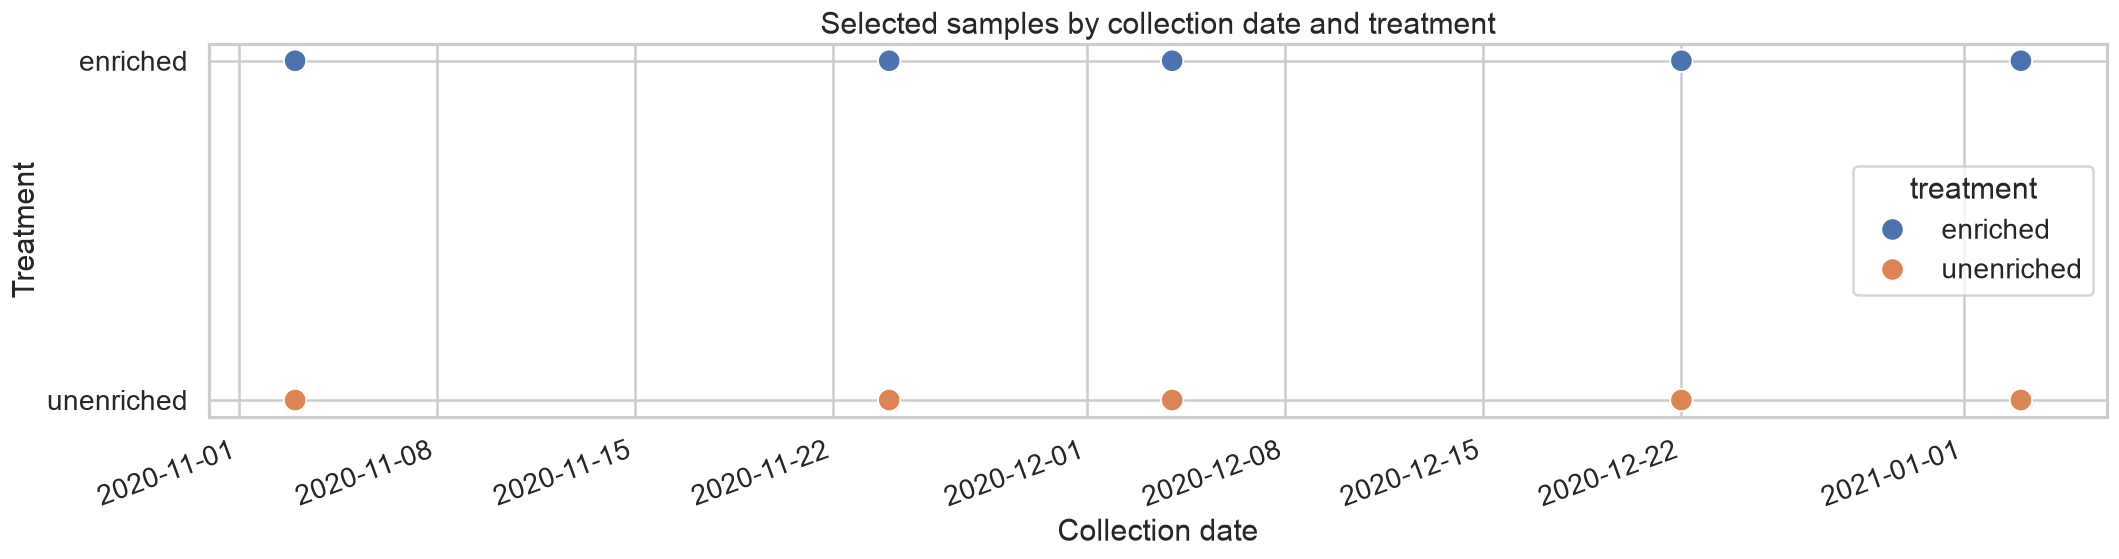

In [24]:
# Sample timeline plot
plt.figure(figsize=(18, 5))
sns.scatterplot(
    data=meta,
    x="date",
    y="treatment",
    hue="treatment",
    s=180
)
plt.title("Selected samples by collection date and treatment")
plt.xticks(rotation=20, ha="right")
plt.xlabel("Collection date")
plt.ylabel("Treatment")
plt.tight_layout()
plt.show()

### Sample Selection MCQ

__Why is it important to compare enriched and unenriched wastewater libraries collected on the same dates from the same plant?__

> A) It isolates treatment-associated differences from site-to-site variation.  
> B) It guarantees identical viral abundances in both libraries.  
> C) It removes the need for quality control.  
> D) It makes host filtering unnecessary.

## Quality Contol (QC)

> Quality control assessed whether sequencing reads were retained at high rates after trimming and whether per-sample quality metrics were sufficient for downstream wastewater viromics analysis. In metatranscriptomic workflows, this step is important because poor-quality or adapter-contaminated reads can distort both taxonomic profiles and variant analyses.

In [14]:
# Merge metadata into QC
qc = qc.merge(
    meta[["sample", "date", "treatment", "site", "is_enriched"]],
    on="sample",
    how="left"
)
qc = qc.sort_values(["date", "treatment"])

display(qc)

,sample,reads_before,reads_after,reads_retained_fraction,bases_before,bases_after,bases_retained_fraction,read1_mean_length_before,read2_mean_length_before,read1_mean_length_after,...,site_x,is_enriched_x,date_y,treatment_y,site_y,is_enriched_y,date,treatment,site,is_enriched
0,HTP_2020-11-03_enriched,2146302,2142140,0.998061,216776502,184670772,0.851895,101,101,86,...,HTP,True,2020-11-03,enriched,HTP,True,2020-11-03,enriched,HTP,True
1,HTP_2020-11-03_unenriched,23069046,23021664,0.997946,2329973646,1973424678,0.846973,101,101,85,...,HTP,False,2020-11-03,unenriched,HTP,False,2020-11-03,unenriched,HTP,False
2,HTP_2020-11-24_enriched,2958648,2953142,0.998139,298823448,254600738,0.852011,101,101,86,...,HTP,True,2020-11-24,enriched,HTP,True,2020-11-24,enriched,HTP,True
3,HTP_2020-11-24_unenriched,22091754,22046204,0.997938,2231267154,1875716082,0.840651,101,101,85,...,HTP,False,2020-11-24,unenriched,HTP,False,2020-11-24,unenriched,HTP,False
4,HTP_2020-12-04_enriched,2529648,2524470,0.997953,255494448,217033802,0.849466,101,101,85,...,HTP,True,2020-12-04,enriched,HTP,True,2020-12-04,enriched,HTP,True
5,HTP_2020-12-04_unenriched,21749208,21704706,0.997954,2196670008,1825957420,0.831239,101,101,84,...,HTP,False,2020-12-04,unenriched,HTP,False,2020-12-04,unenriched,HTP,False
6,HTP_2020-12-22_enriched,2596840,2591128,0.997800,262280840,225386036,0.859331,101,101,86,...,HTP,True,2020-12-22,enriched,HTP,True,2020-12-22,enriched,HTP,True
7,HTP_2020-12-22_unenriched,17723052,17692114,0.998254,1790028252,1432840284,0.800457,101,101,80,...,HTP,False,2020-12-22,unenriched,HTP,False,2020-12-22,unenriched,HTP,False
8,HTP_2021-01-03_enriched,1980758,1976752,0.997978,200056558,170009314,0.849806,101,101,86,...,HTP,True,2021-01-03,enriched,HTP,True,2021-01-03,enriched,HTP,True
9,HTP_2021-01-03_unenriched,19252914,19218084,0.998191,1944544314,1607732216,0.826791,101,101,83,...,HTP,False,2021-01-03,unenriched,HTP,False,2021-01-03,unenriched,HTP,False


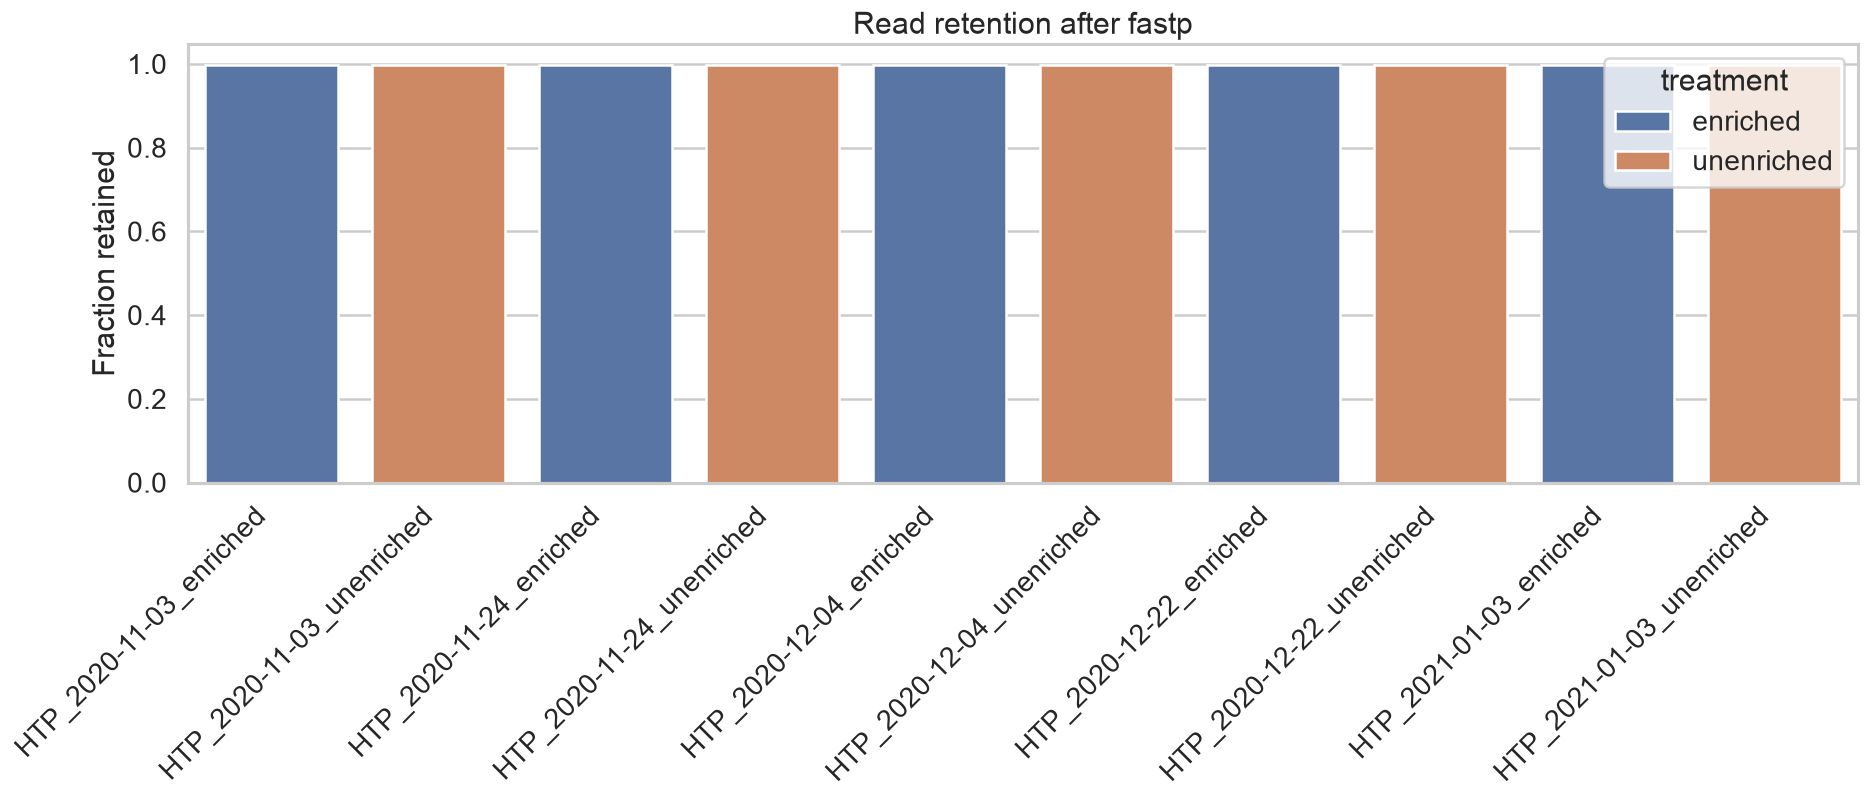

In [16]:
# Read Retention Plot
plt.figure(figsize=(16, 7))
sns.barplot(
    data=qc,
    x="sample",
    y="reads_retained_fraction",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction retained")
plt.xlabel("")
plt.title("Read retention after fastp")
plt.tight_layout()
plt.show()

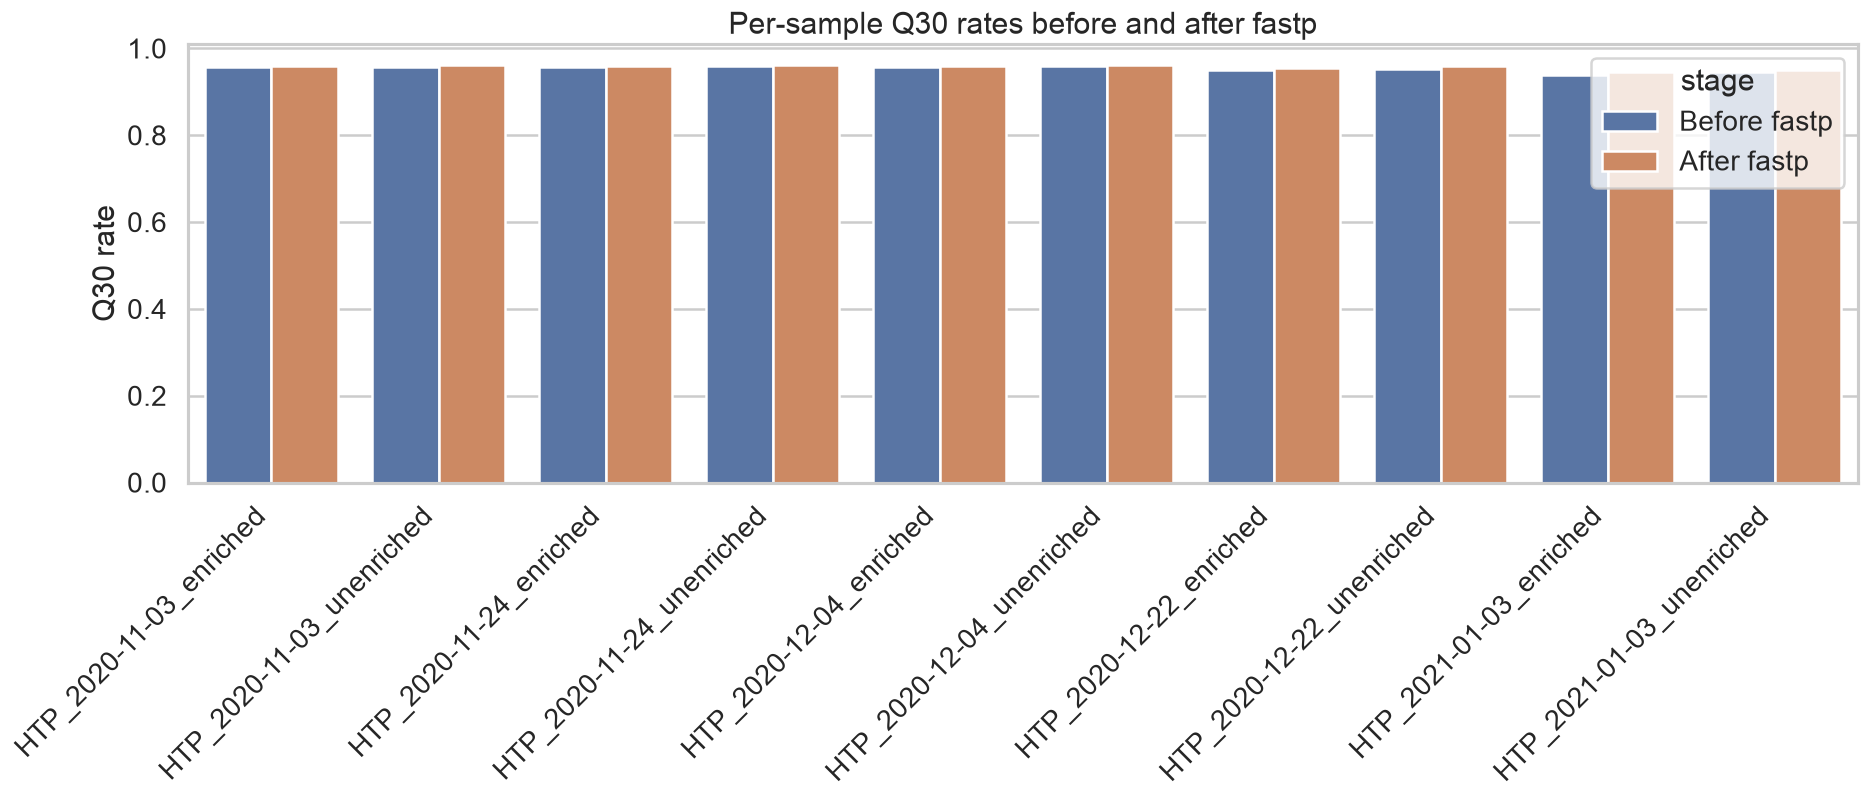

In [18]:
# Q30 before/after plot
qc_long = qc.melt(
    id_vars=["sample", "date", "treatment"],
    value_vars=["q30_rate_before", "q30_rate_after"],
    var_name="stage",
    value_name="q30_rate"
)

qc_long["stage"] = qc_long["stage"].map({
    "q30_rate_before": "Before fastp",
    "q30_rate_after": "After fastp"
})

plt.figure(figsize=(16, 7))
sns.barplot(
    data=qc_long,
    x="sample",
    y="q30_rate",
    hue="stage"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Q30 rate")
plt.xlabel("")
plt.title("Per-sample Q30 rates before and after fastp")
plt.tight_layout()
plt.show()

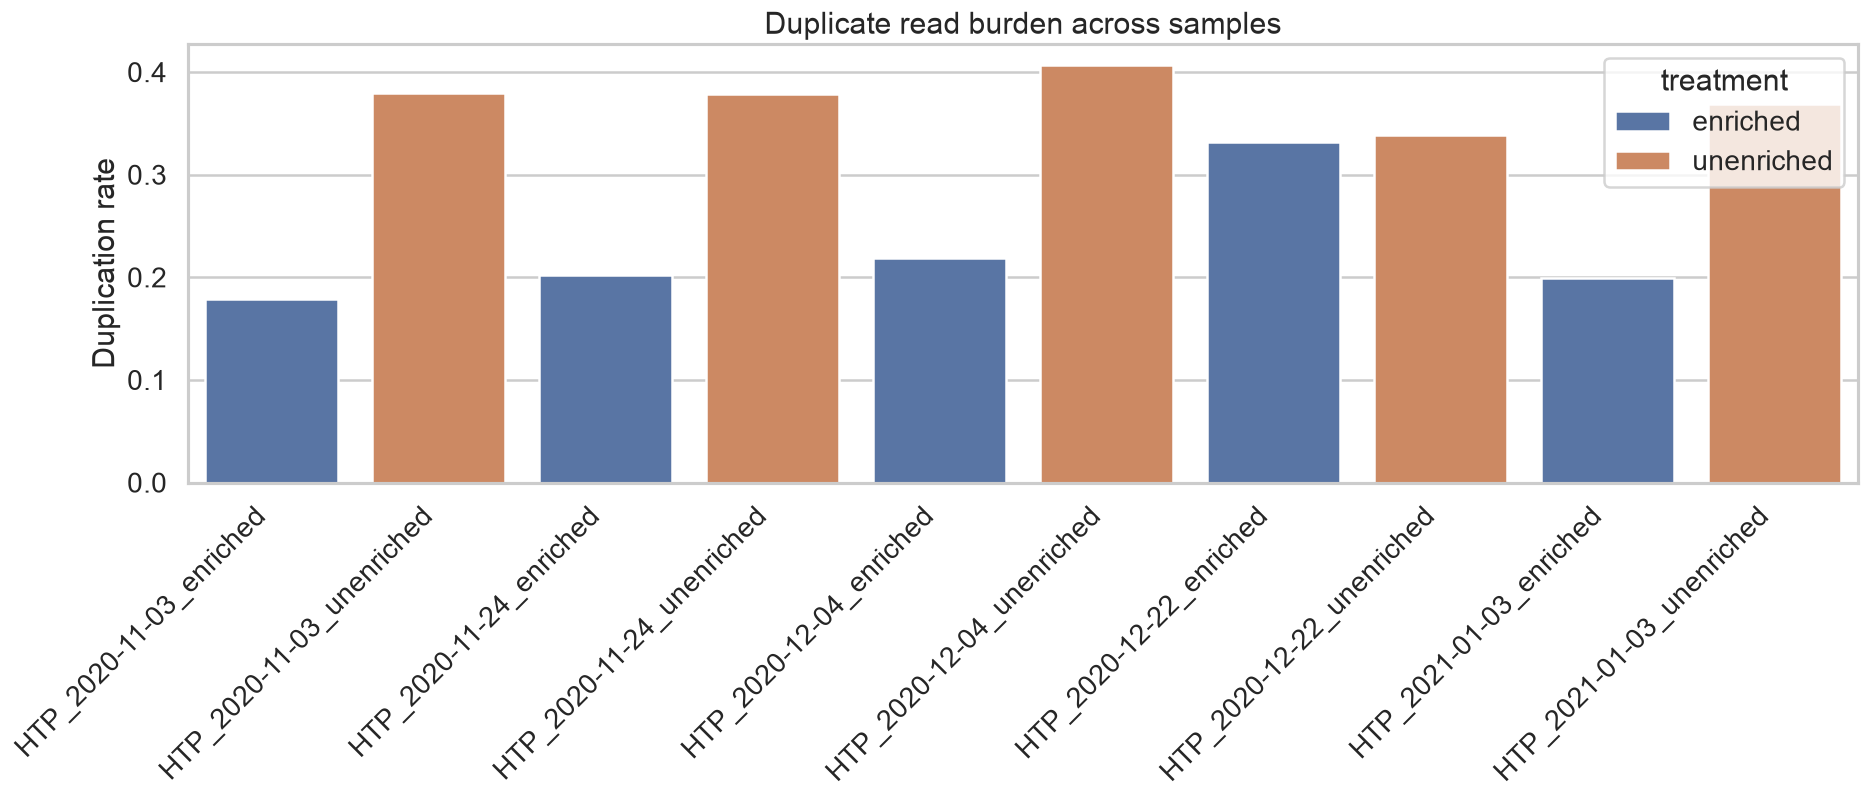

In [19]:
# Duplication rate plot
plt.figure(figsize=(16, 7))
sns.barplot(
    data=qc,
    x="sample",
    y="duplication_rate",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Duplication rate")
plt.xlabel("")
plt.title("Duplicate read burden across samples")
plt.tight_layout()
plt.show()

#### QC Interpretation
> The QC results indicate whether sequencing quality is consistently adequate across all libraries and whether trimming materially improves read quality without sacrificing too much data. The key biological question is whether these libraries remain suitable for downstream comparison of wastewater viral composition and, where coverage permits, SNV analysis.

### Quality Control MCQ

__Which conclusion is best supported if most reads are retained after fastp and Q30 values remain high across samples?__

>A) The sequencing data are suitable for downstream viromics analysis.  
>B) The samples should be discarded because trimming did not remove enough reads.  
>C) QC cannot affect taxonomic analysis.  
>D) Only enriched samples can be analyzed further.

## Host filtering

Host filtering removes reads mapping to the human genome so downstream taxonomic analyses emphasize non-host biological signal. In wastewater RNA data, this step reduces background host-derived reads and focuses attention on microbial and viral composition.

In [25]:
# Merge metadata into host summary
host = host.merge(
    meta[["sample", "date", "treatment", "site", "is_enriched"]],
    on="sample",
    how="left"
)
host = host.sort_values(["date", "treatment"])

display(host)

,sample,bam,total_reads,mapped_reads,unmapped_reads,both_mates_unmapped,mapped_fraction,unmapped_fraction,both_mates_unmapped_fraction,date,treatment,site,is_enriched
0,HTP_2020-11-03_enriched,results/host_filter/bwa/HTP_2020-11-03_enriche...,115592,39406,76186,76022,0.340906,0.659094,0.657675,2020-11-03,enriched,HTP,True
1,HTP_2020-11-03_unenriched,results/host_filter/bwa/HTP_2020-11-03_unenric...,114734,35020,79714,79572,0.305228,0.694772,0.693535,2020-11-03,unenriched,HTP,False
2,HTP_2020-11-24_enriched,results/host_filter/bwa/HTP_2020-11-24_enriche...,115580,40758,74822,74694,0.352639,0.647361,0.646254,2020-11-24,enriched,HTP,True
3,HTP_2020-11-24_unenriched,results/host_filter/bwa/HTP_2020-11-24_unenric...,115669,37749,77920,77796,0.326354,0.673646,0.672574,2020-11-24,unenriched,HTP,False
4,HTP_2020-12-04_enriched,results/host_filter/bwa/HTP_2020-12-04_enriche...,115049,40190,74859,74718,0.349329,0.650671,0.649445,2020-12-04,enriched,HTP,True
5,HTP_2020-12-04_unenriched,results/host_filter/bwa/HTP_2020-12-04_unenric...,116020,39361,76659,76554,0.339260,0.660740,0.659835,2020-12-04,unenriched,HTP,False
6,HTP_2020-12-22_enriched,results/host_filter/bwa/HTP_2020-12-22_enriche...,116918,42721,74197,73892,0.365393,0.634607,0.631998,2020-12-22,enriched,HTP,True
7,HTP_2020-12-22_unenriched,results/host_filter/bwa/HTP_2020-12-22_unenric...,119880,41058,78822,78638,0.342492,0.657508,0.655973,2020-12-22,unenriched,HTP,False
8,HTP_2021-01-03_enriched,results/host_filter/bwa/HTP_2021-01-03_enriche...,116338,39652,76686,76606,0.340834,0.659166,0.658478,2021-01-03,enriched,HTP,True
9,HTP_2021-01-03_unenriched,results/host_filter/bwa/HTP_2021-01-03_unenric...,116880,36514,80366,80284,0.312406,0.687594,0.686893,2021-01-03,unenriched,HTP,False


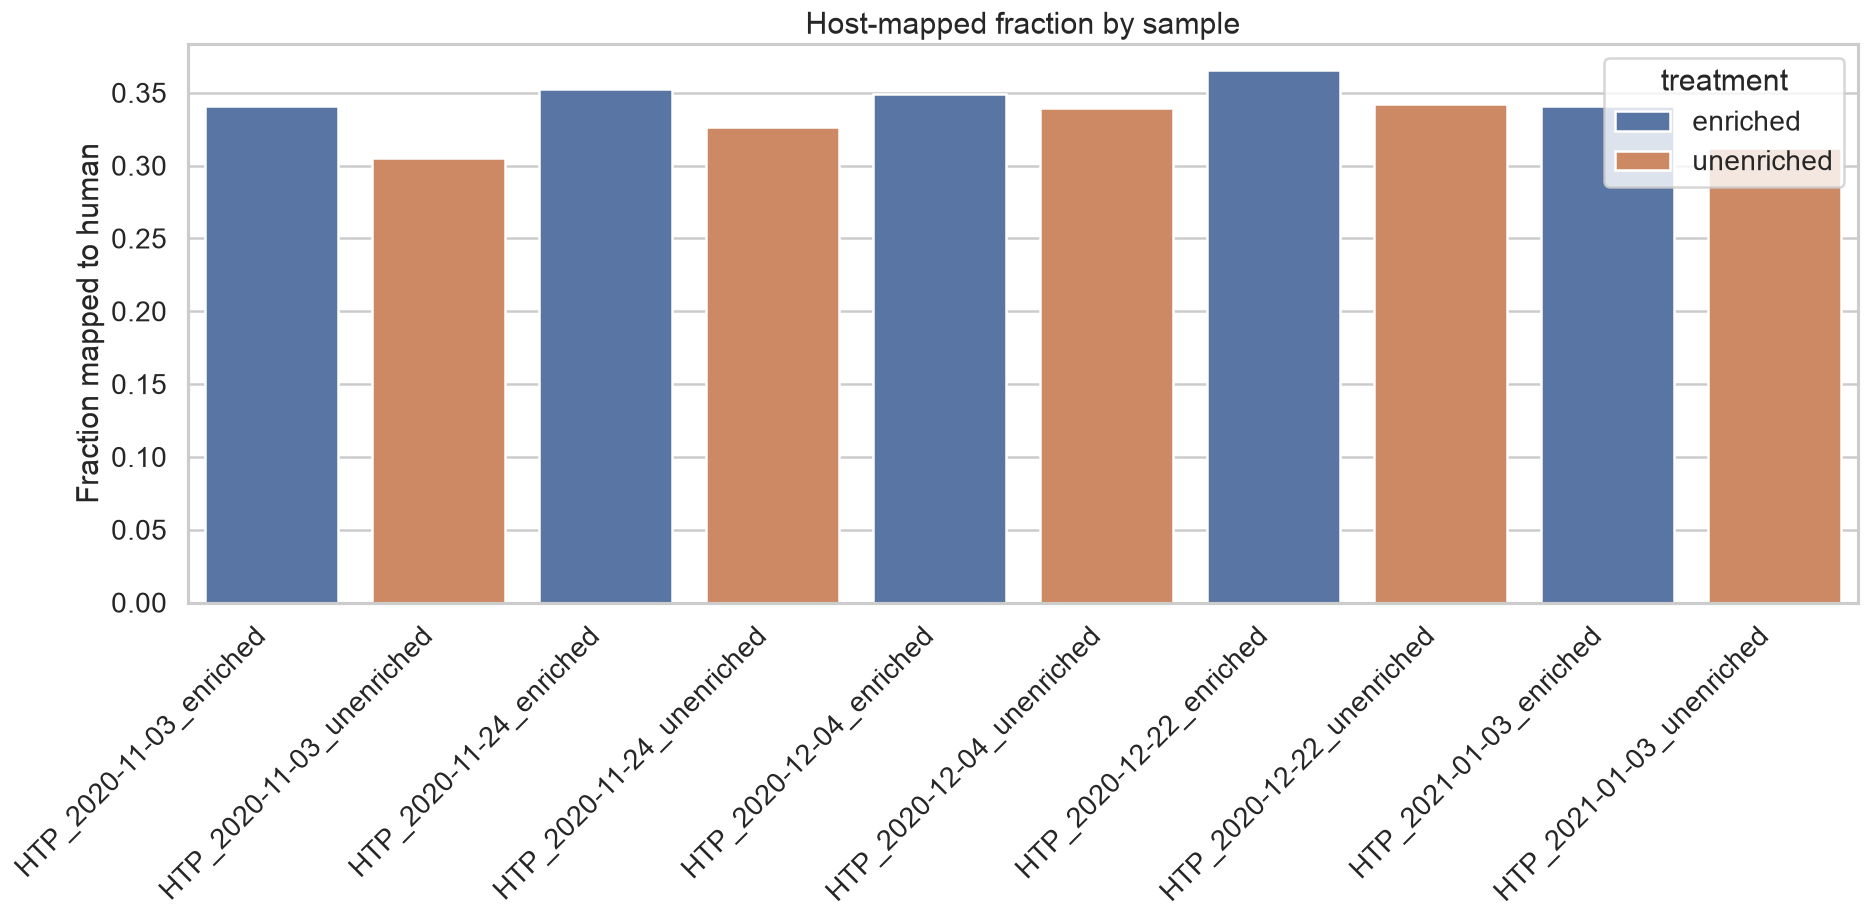

In [31]:
# Host-mapped fraction plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=host,
    x="sample",
    y="mapped_fraction",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction mapped to human")
plt.xlabel("")
plt.title("Host-mapped fraction by sample")
plt.tight_layout()
plt.show()

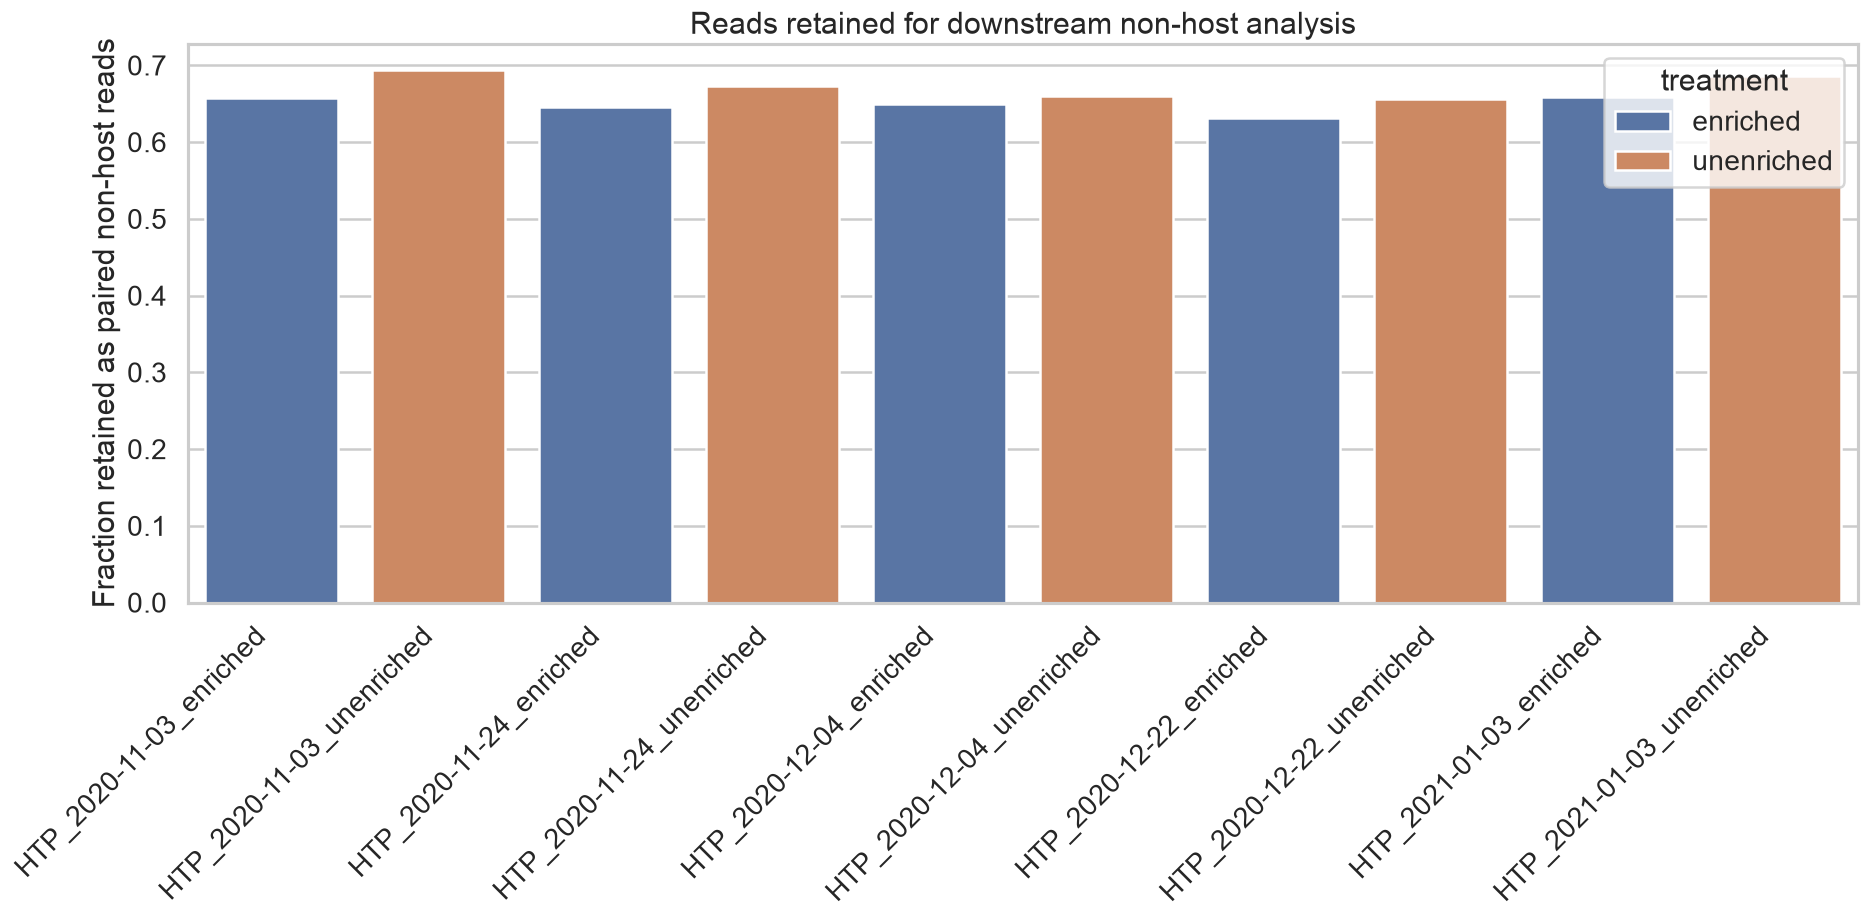

In [33]:
# Non-host retained fraction plot
plt.figure(figsize=(16, 8))
sns.barplot(
    data=host,
    x="sample",
    y="both_mates_unmapped_fraction",
    hue="treatment"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction retained as paired non-host reads")
plt.xlabel("")
plt.title("Reads retained for downstream non-host analysis")
plt.tight_layout()
plt.show()

### Host Filtering MCQ

__What is the main purpose of host filtering in this wastewater metatranscriptomic workflow?__

>A) To remove background human-derived reads before taxonomic profiling.  
>B) To directly identify viral SNVs.  
>C) To normalize sequencing depth across samples.  
>D) To classify all viral species without a reference database.

## Taxonomic composition

> Broad taxonomic composition provides context for the non-host RNA background present in wastewater and helps interpret whether enrichment changes the observable community profile. Because the source study is virome-focused, this section mainly contextualizes the more detailed viral abundance analysis.

In [51]:
# Inspect merged bracken results table structure
print("Genus shape:", None if genus is None else genus.shape)
print("Species shape:", None if species is None else species.shape)

if genus is not None:
    display(genus.head())

if species is not None:
    display(species.head())

Genus shape: (248, 13)
Species shape: (245, 13)


,taxon,taxonomy_id,taxonomy_lvl,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Pseudomonas,286,G,1345.0,1034.0,1074.0,1062.0,2027.0,1517.0,947.0,1215.0,470.0,511.0
1,Salmonella,590,G,2964.0,2742.0,1652.0,2427.0,1638.0,1454.0,2141.0,2811.0,1563.0,2143.0
2,Klebsiella,570,G,163.0,273.0,337.0,157.0,169.0,259.0,384.0,354.0,199.0,246.0
3,Enterobacter,547,G,314.0,232.0,262.0,269.0,182.0,180.0,204.0,445.0,299.0,337.0
4,Escherichia,561,G,143.0,185.0,96.0,264.0,115.0,379.0,163.0,172.0,141.0,112.0


,taxon,taxonomy_id,taxonomy_lvl,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Pseudomonas marginalis,298,S,60.0,70.0,32.0,43.0,19.0,53.0,88.0,63.0,66.0,100.0
1,Pseudomonas fluorescens,294,S,16.0,23.0,0.0,12.0,0.0,0.0,0.0,12.0,0.0,31.0
2,Pseudomonas aeruginosa,287,S,1197.0,805.0,984.0,847.0,1747.0,1169.0,725.0,561.0,301.0,292.0
3,Pseudomonas syringae,317,S,13.0,13.0,13.0,0.0,0.0,21.0,0.0,0.0,0.0,0.0
4,Salmonella enterica,28901,S,3628.0,3560.0,2536.0,2667.0,1927.0,1730.0,3133.0,3438.0,1996.0,2457.0


In [52]:
# Helper to id sample columns
sample_order = meta.sort_values(["date", "treatment"])["sample"].tolist()
sample_set = set(sample_order)

def get_sample_columns(df, sample_names):
    return [c for c in df.columns if c in sample_names]

genus_sample_cols = get_sample_columns(genus, sample_set) if genus is not None else []
species_sample_cols = get_sample_columns(species, sample_set) if species is not None else []

print("Genus sample columns:", genus_sample_cols[:5], "...", len(genus_sample_cols))
print("Species sample columns:", species_sample_cols[:5], "...", len(species_sample_cols))

Genus sample columns: ['HTP_2020-11-03_enriched', 'HTP_2020-11-03_unenriched', 'HTP_2020-11-24_enriched', 'HTP_2020-11-24_unenriched', 'HTP_2020-12-04_enriched'] ... 10
Species sample columns: ['HTP_2020-11-03_enriched', 'HTP_2020-11-03_unenriched', 'HTP_2020-11-24_enriched', 'HTP_2020-11-24_unenriched', 'HTP_2020-12-04_enriched'] ... 10


In [53]:
# choose taxon name column
def guess_taxon_col(df):
    candidates = ["name", "taxon_name", "taxonomy", "genus", "species"]
    for c in candidates:
        if c in df.columns:
            return c
    return df.columns[0]

genus_taxon_col = guess_taxon_col(genus) if genus is not None else None
species_taxon_col = guess_taxon_col(species) if species is not None else None

print("Genus taxon column:", genus_taxon_col)
print("Species taxon column:", species_taxon_col)

Genus taxon column: taxon
Species taxon column: taxon


In [54]:
# convert to relative abundance
def make_relative_abundance(df, taxon_col, sample_cols):
    out = df[[taxon_col] + sample_cols].copy()
    out = out.groupby(taxon_col, as_index=False)[sample_cols].sum()
    col_sums = out[sample_cols].sum(axis=0)
    out[sample_cols] = out[sample_cols].div(col_sums.replace(0, np.nan), axis=1).fillna(0)
    return out

genus_rel = make_relative_abundance(genus, genus_taxon_col, genus_sample_cols) if genus is not None else None
species_rel = make_relative_abundance(species, species_taxon_col, species_sample_cols) if species is not None else None

if genus_rel is not None:
    display(genus_rel.head())

if species_rel is not None:
    display(species_rel.head())

,taxon,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Acetoanaerobium,0.000810,0.000834,0.00000,0.001066,0.000764,0.000985,0.001015,0.001092,0.000727,0.000710
1,Acetobacteroides,0.002254,0.002121,0.00218,0.002171,0.002438,0.003130,0.006249,0.004115,0.001928,0.002625
2,Achromobacter,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000619,0.000000,0.000000
3,Acidihalobacter,0.000000,0.000487,0.00000,0.000553,0.000000,0.000000,0.000508,0.000437,0.000000,0.000532
4,Acidovorax,0.001796,0.007787,0.00560,0.005959,0.011026,0.011287,0.012067,0.015220,0.019096,0.026396


,taxon,HTP_2020-11-03_enriched,HTP_2020-11-03_unenriched,HTP_2020-11-24_enriched,HTP_2020-11-24_unenriched,HTP_2020-12-04_enriched,HTP_2020-12-04_unenriched,HTP_2020-12-22_enriched,HTP_2020-12-22_unenriched,HTP_2021-01-03_enriched,HTP_2021-01-03_unenriched
0,Acidihalobacter ferrooxydans,0.0,0.000493,0.0,0.000558,0.000000,0.000000,0.000552,0.000439,0.000000,0.000000
1,Acidovorax carolinensis,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003213
2,Acidovorax temperans,0.0,0.009018,0.0,0.006443,0.012564,0.013583,0.014214,0.017428,0.022121,0.025819
3,Acinetobacter baumannii,0.0,0.003410,0.0,0.000000,0.000000,0.004605,0.000000,0.006341,0.000000,0.003677
4,Adlercreutzia equolifaciens,0.0,0.001288,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [56]:
# top taxa selection
def top_taxa_table(rel_df, taxon_col, sample_cols, top_n=40):
    ranked = rel_df.assign(total_abundance=rel_df[sample_cols].sum(axis=1))
    ranked = ranked.sort_values("total_abundance", ascending=False).head(top_n)
    return ranked[[taxon_col] + sample_cols]

genus_top = top_taxa_table(genus_rel, genus_taxon_col, genus_sample_cols, top_n=40) if genus_rel is not None else None
species_top = top_taxa_table(species_rel, species_taxon_col, species_sample_cols, top_n=40) if species_rel is not None else None

In [57]:
# reorder columns by time / treatment
ordered_genus_cols = [s for s in sample_order if s in genus_sample_cols]
ordered_species_cols = [s for s in sample_order if s in species_sample_cols]

if genus_top is not None:
    genus_top = genus_top[[genus_taxon_col] + ordered_genus_cols]

if species_top is not None:
    species_top = species_top[[species_taxon_col] + ordered_species_cols]

### Heatmaps

In [62]:
# Heatmap helper
def plot_taxonomy_heatmap(
    df,
    title,
    cmap="mako",
    log_transform=True,
    pseudocount=1e-6,
    show_every=1,
    min_height=8,
    row_height=0.28,
    y_fontsize=7,
    x_fontsize=9
):
    plot_df = df.copy()

    if log_transform:
        plot_df = np.log10(plot_df + pseudocount)

    n_rows = plot_df.shape[0]
    fig_height = max(min_height, n_rows * row_height)

    fig, ax = plt.subplots(figsize=(14, fig_height))
    sns.heatmap(
        plot_df,
        cmap=cmap,
        ax=ax,
        yticklabels=True,
        xticklabels=True,
        cbar_kws={
            "label": "log10(relative abundance)" if log_transform else "relative abundance"
        }
    )

    ax.set_title(title)
    ax.set_xlabel("Sample")
    ax.set_ylabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=x_fontsize)

    ylabels = plot_df.index.tolist()
    ypositions = np.arange(len(ylabels)) + 0.5

    if show_every > 1:
        ypositions = ypositions[::show_every]
        ylabels = ylabels[::show_every]

    ax.set_yticks(ypositions)
    ax.set_yticklabels(ylabels, rotation=0, fontsize=y_fontsize, va="center")

    plt.tight_layout()
    plt.show()

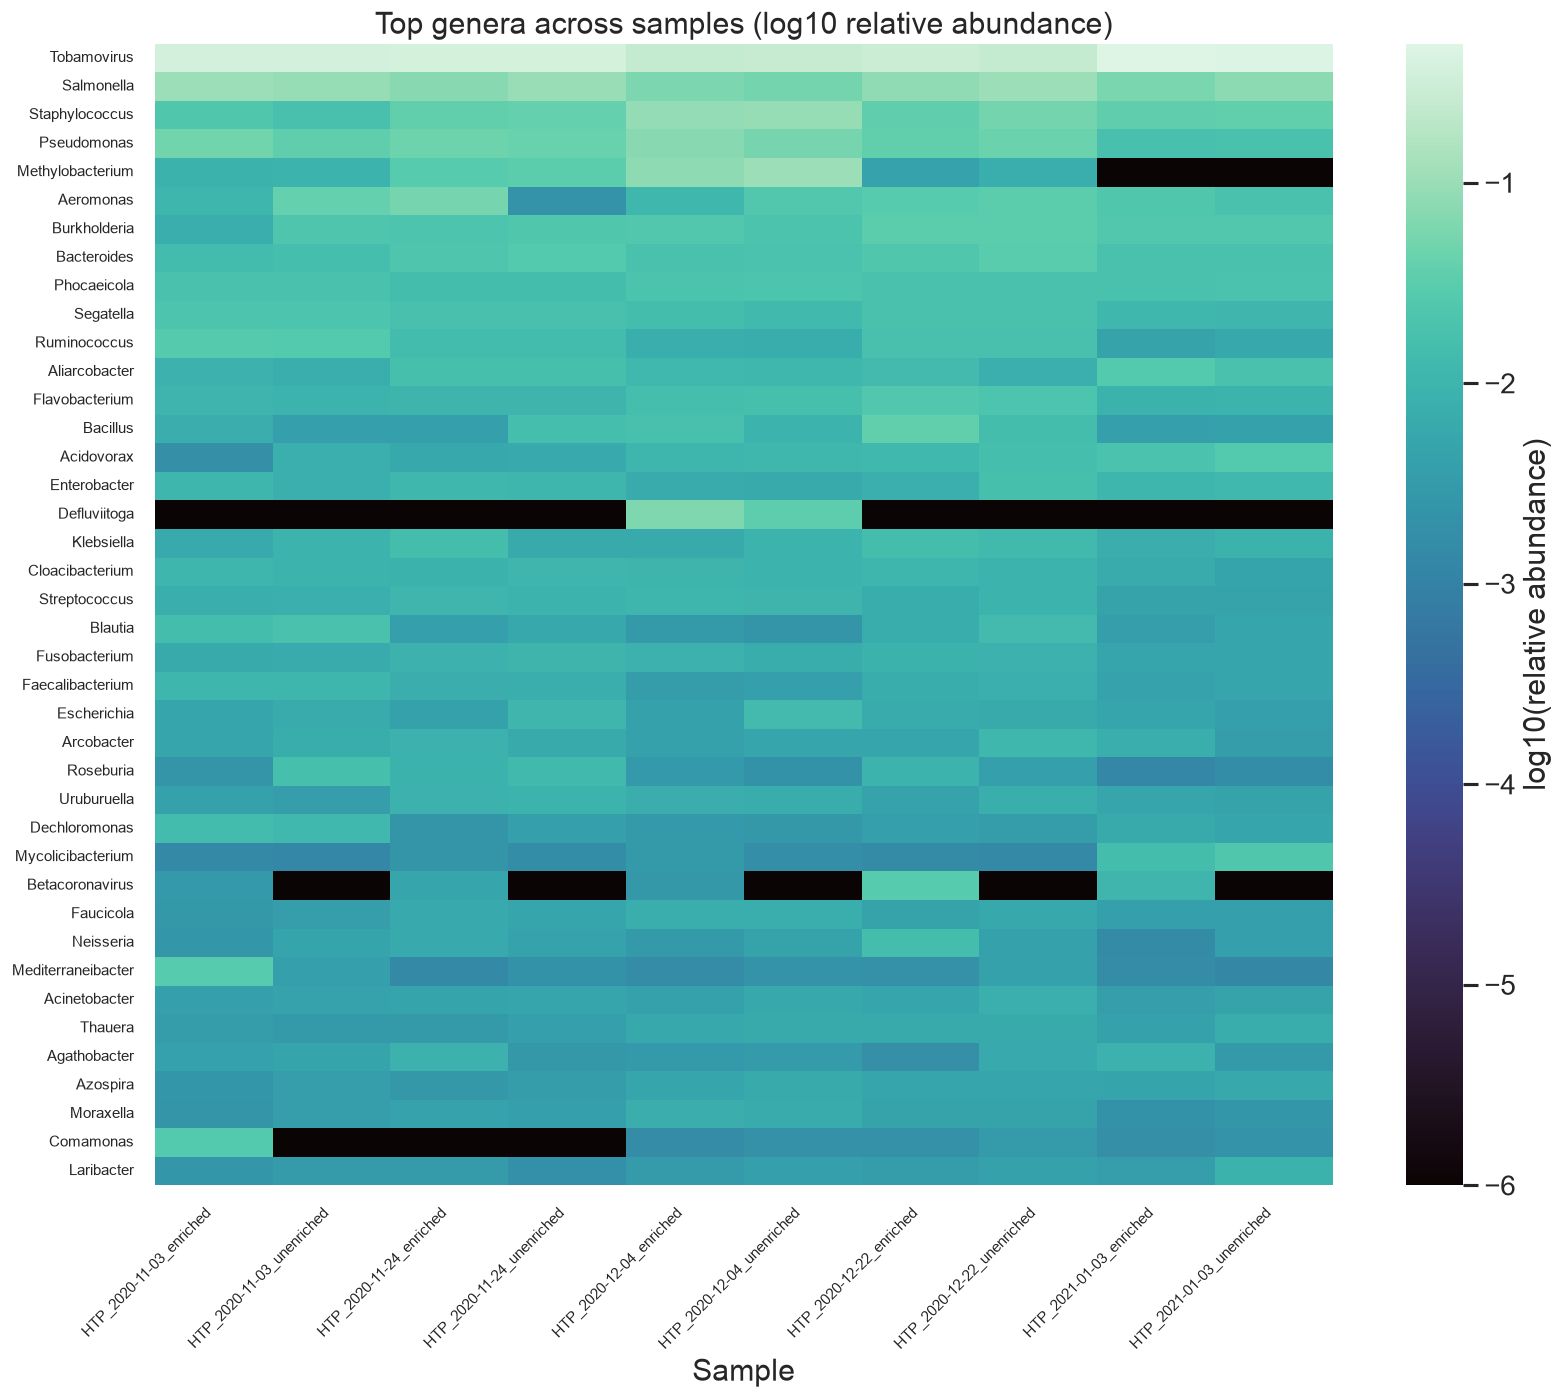

In [67]:
# Genus Heatmap
if genus_top is not None:
    genus_heat = genus_top.set_index(genus_taxon_col)

    plot_taxonomy_heatmap(
        genus_heat,
        title="Top genera across samples (log10 relative abundance)",
        cmap="mako",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,
        min_height=8,
        row_height=0.30,
        y_fontsize=9,
        x_fontsize=9
    )

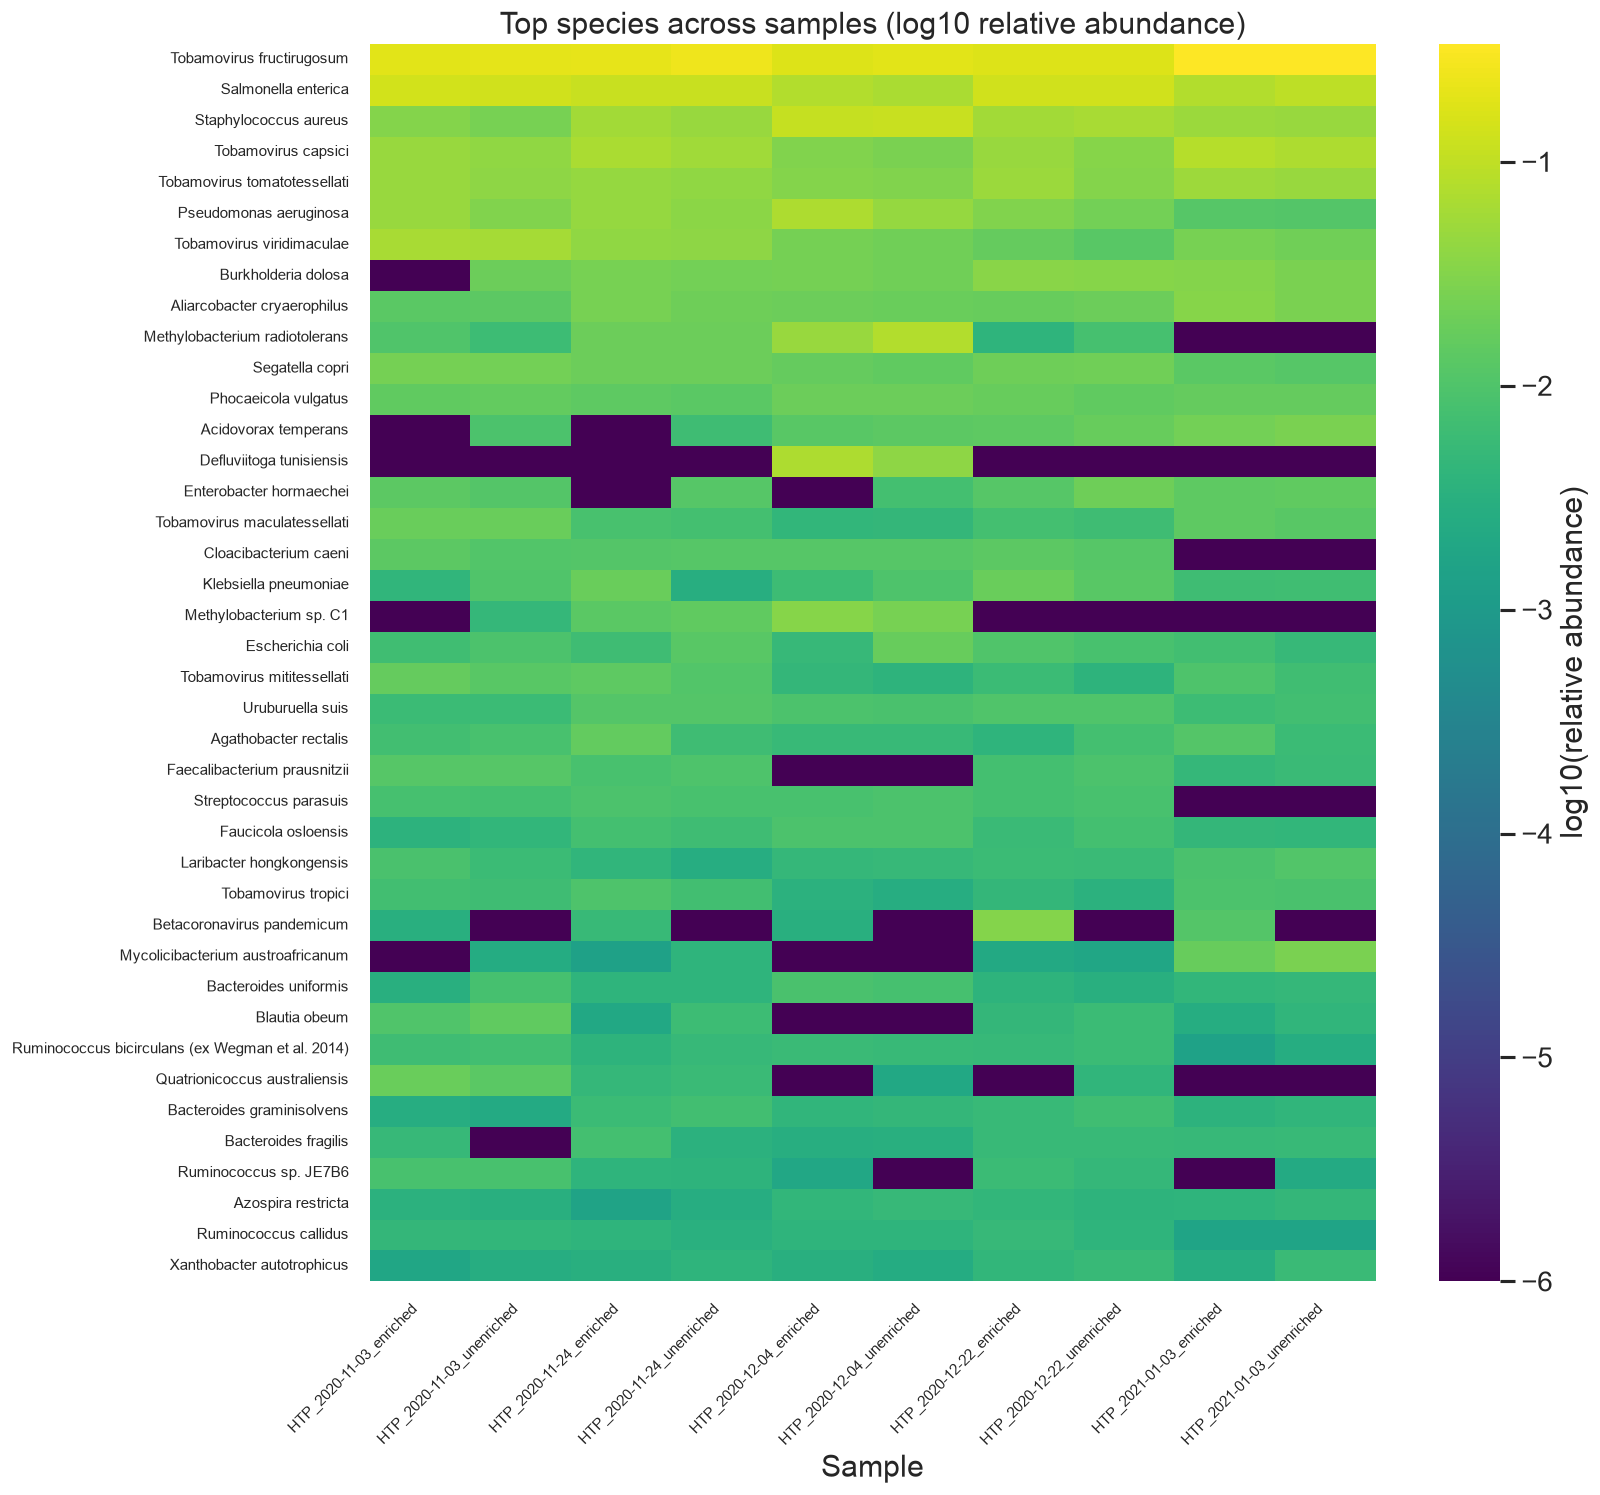

In [68]:
# Species heatmap
# Species Heatmap
if species_top is not None:
    species_heat = species_top.set_index(species_taxon_col)

    plot_taxonomy_heatmap(
        species_heat,
        title="Top species across samples (log10 relative abundance)",
        cmap="viridis",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,   # change to 2 if labels are still crowded
        min_height=8,
        row_height=0.32,
        y_fontsize=9,
        x_fontsize=9
    )

> Heatmaps were plotted using log10-transformed relative abundances because the taxonomic abundance distributions were highly skewed. This transformation reduced dominance by the most abundant taxa and improved visibility of temporal structure among moderately and low-abundance taxa. A small pseudocount was added before transformation so taxa with zero abundance in individual samples could still be included in the visualization.

> Broad taxonomic heatmaps were used to summarize how the wastewater community profile changed across time and treatment conditions. Heatmaps were preferred over stacked bar plots because they preserve visibility of many taxa simultaneously, including moderately and low-abundance taxa that would be difficult to interpret in highly compositional bar charts.
>
> The genus- and species-level heatmaps show that the wastewater metatranscriptomic background is taxonomically broad and varies across collection dates. Comparing matched enriched and unenriched samples helps distinguish temporal shifts in community composition from treatment-associated shifts in recoverable taxa.

### Clustered Heatmaps

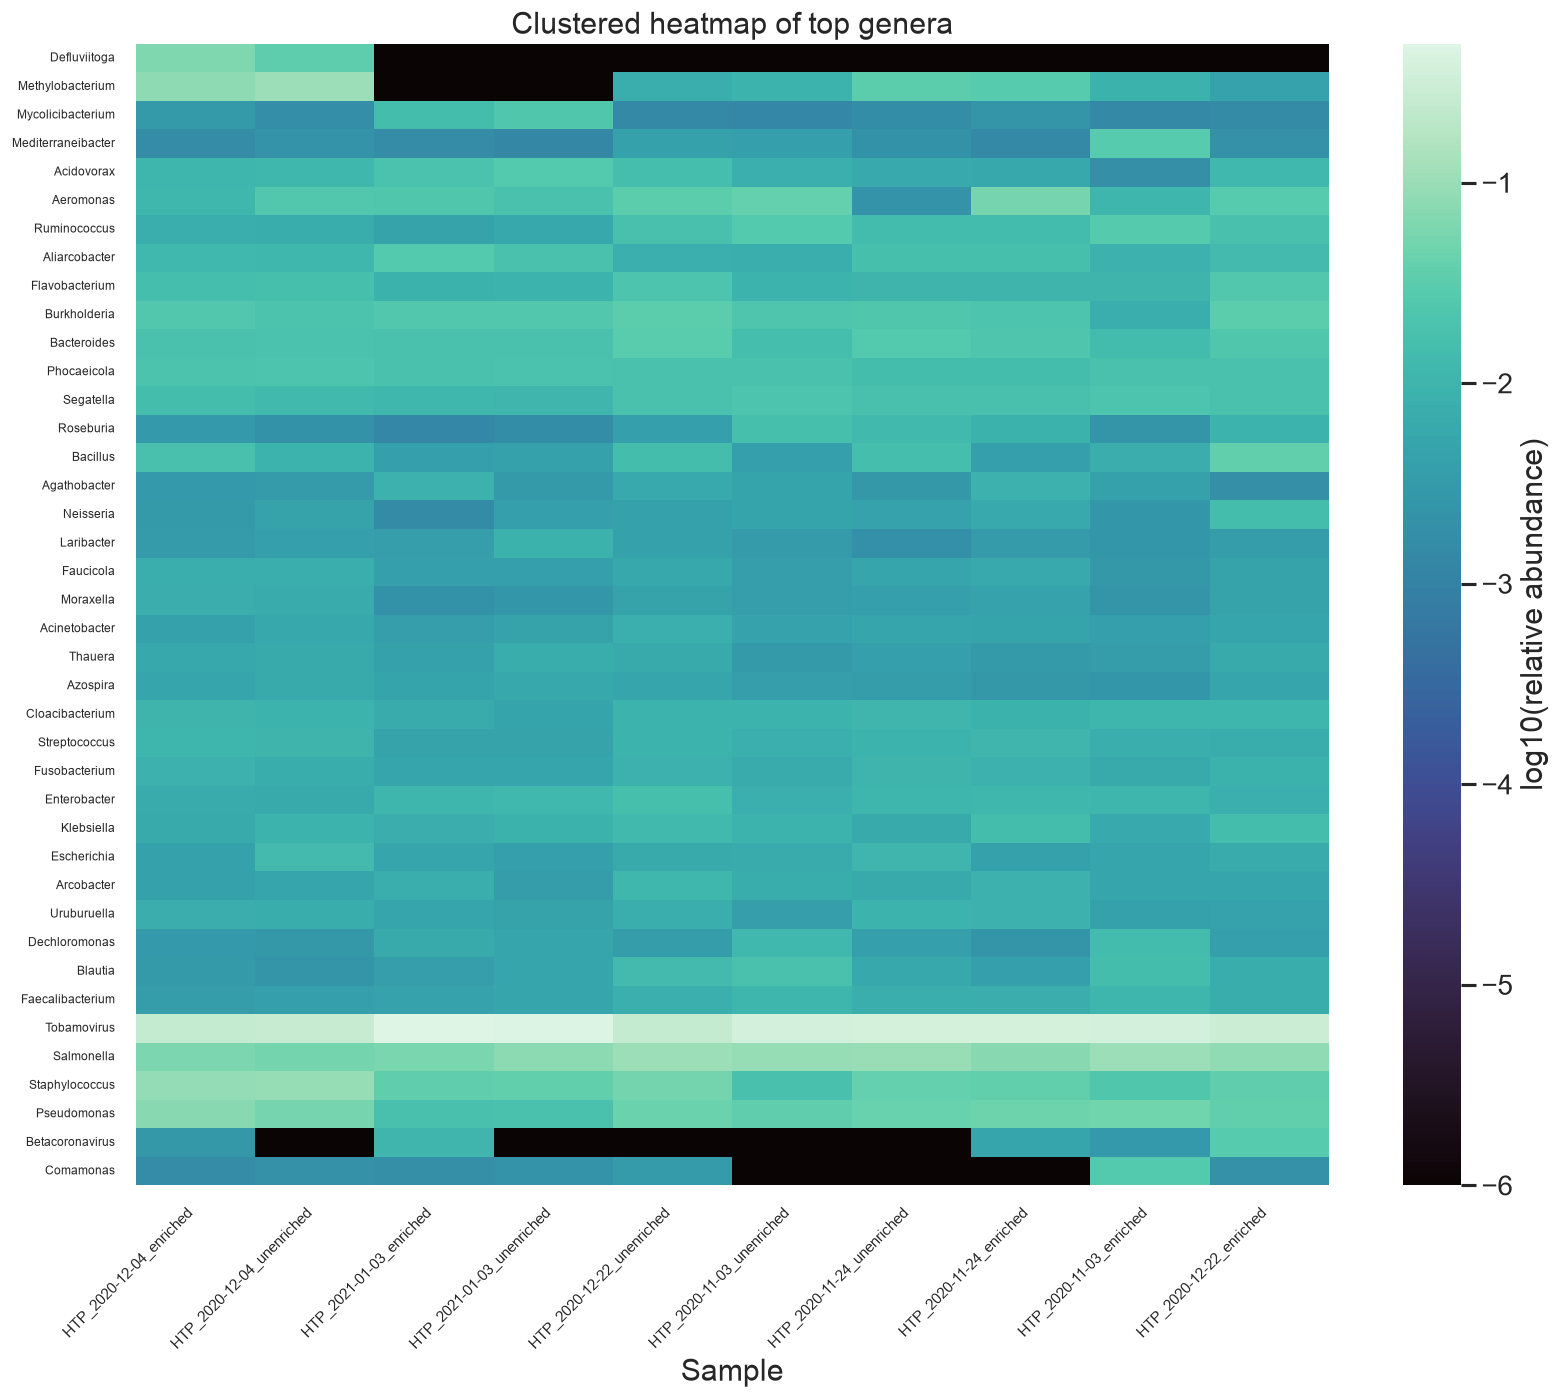

In [79]:
# genus clustered heatmap
if genus_top is not None:
    genus_cluster = genus_top.set_index(genus_taxon_col).copy()
    genus_cluster_log = np.log10(genus_cluster + 1e-6)

    row_linkage = linkage(pdist(genus_cluster_log.values, metric="euclidean"), method="average")
    col_linkage = linkage(pdist(genus_cluster_log.T.values, metric="euclidean"), method="average")

    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)

    genus_clustered = genus_cluster.iloc[row_order, col_order]

    plot_taxonomy_heatmap(
        genus_clustered,
        title="Clustered heatmap of top genera",
        cmap="mako",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,
        min_height=8,
        row_height=0.30,
        y_fontsize=7,
        x_fontsize=9
    )

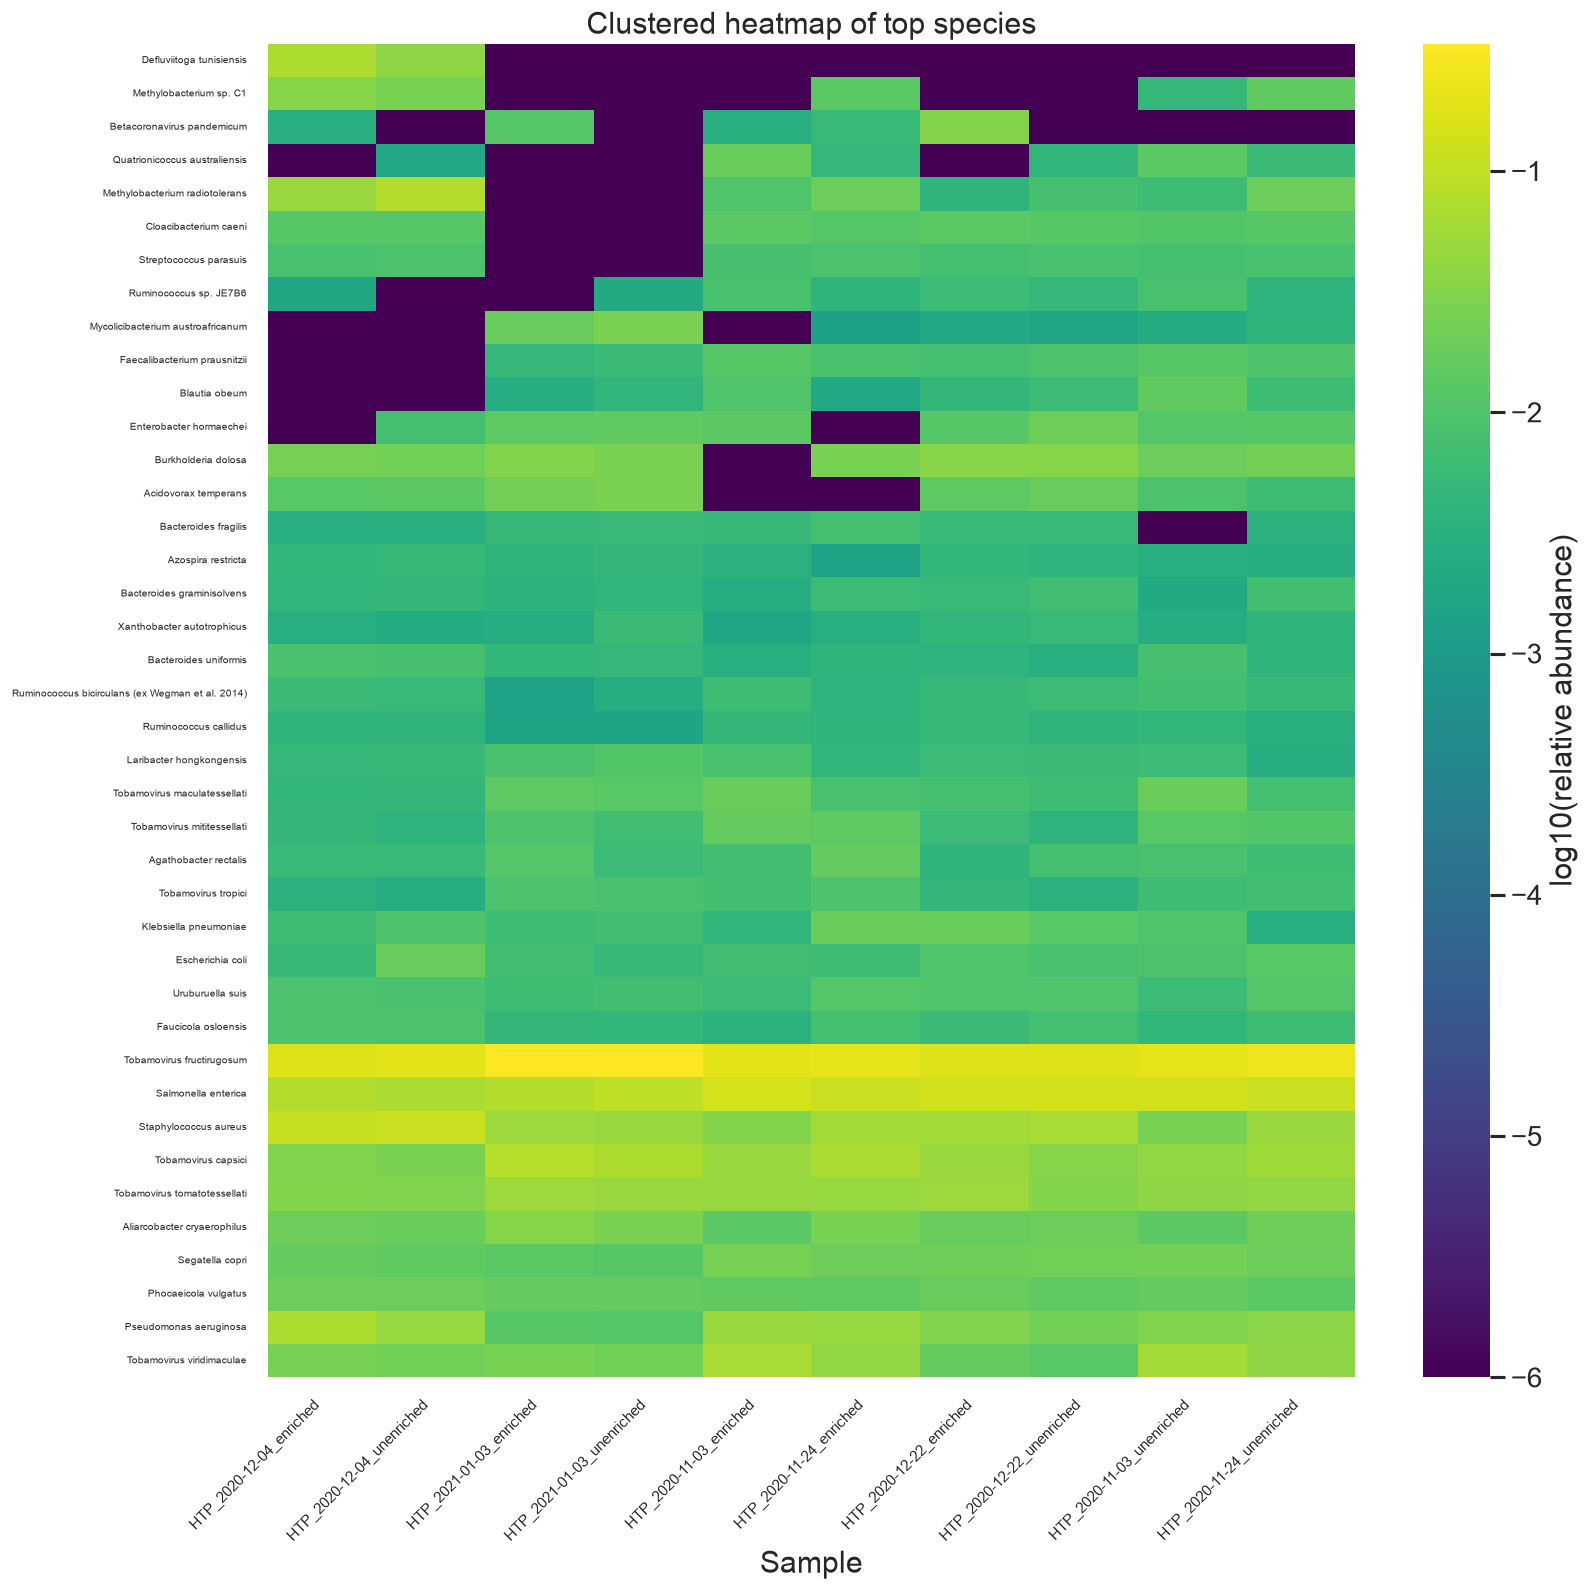

In [80]:
# Species clustered heatmap
from scipy.cluster.hierarchy import linkage, leaves_list

from scipy.spatial.distance import pdist

if species_top is not None:
    species_cluster = species_top.set_index(species_taxon_col).copy()
    species_cluster_log = np.log10(species_cluster + 1e-6)

    row_linkage = linkage(pdist(species_cluster_log.values, metric="euclidean"), method="average")
    col_linkage = linkage(pdist(species_cluster_log.T.values, metric="euclidean"), method="average")

    row_order = leaves_list(row_linkage)
    col_order = leaves_list(col_linkage)

    species_clustered = species_cluster.iloc[row_order, col_order]

    plot_taxonomy_heatmap(
        species_clustered,
        title="Clustered heatmap of top species",
        cmap="viridis",
        log_transform=True,
        pseudocount=1e-6,
        show_every=1,     # or 2 if needed
        min_height=8,
        row_height=0.34,
        y_fontsize=6,
        x_fontsize=9
    )

> To improve interpretability, clustered heatmaps were generated using the same top taxa shown in the standard ordered heatmaps. Restricting clustering to the most abundant taxa preserved comparability between figures while avoiding visually overloaded dendrograms dominated by very low-abundance taxa.
>
> To improve interpretability, species profiles were hierarchically clustered and then replotted as an ordered heatmap rather than using the default clustered heatmap rendering directly. This preserved the clustering-derived ordering while allowing explicit control of row-label placement and readability for dense species-level taxonomic data.

## Viral relative abundance

> Species-level viral relative abundance is the core analysis in this notebook because the main biological question concerns how wastewater viral composition changes across time and between enriched and unenriched libraries. This section focuses on dominant viral taxa and how enrichment reshapes the observed virome.

In [36]:
# Clean viral table
viral["date"] = pd.to_datetime(viral["date"])
viral = viral.sort_values(["date", "treatment", "reads"], ascending=[True, True, False])

display(viral.head(20))

,sample,site,date,treatment,taxonomy_lvl,taxonomy_id,name,reads,viral_total_reads,relative_abundance,is_viral,is_sars_cov_2
0,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432872,Tobamovirus fructirugosum,4742.0,10136.0,0.467837,True,False
1,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432895,Tobamovirus viridimaculae,1585.0,10136.0,0.156373,True,False
2,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432892,Tobamovirus tomatotessellati,1227.0,10136.0,0.121054,True,False
3,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432865,Tobamovirus capsici,1215.0,10136.0,0.119870,True,False
4,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432877,Tobamovirus maculatessellati,462.0,10136.0,0.045580,True,False
5,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432879,Tobamovirus mititessellati,416.0,10136.0,0.041042,True,False
6,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3432893,Tobamovirus tropici,178.0,10136.0,0.017561,True,False
7,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,3418604,Betacoronavirus pandemicum,80.0,10136.0,0.007893,True,True
8,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,1923145,Hubei picorna-like virus 62,66.0,10136.0,0.006511,True,False
9,HTP_2020-11-03_enriched,HTP,2020-11-03,enriched,S,1923146,Hubei picorna-like virus 63,50.0,10136.0,0.004933,True,False


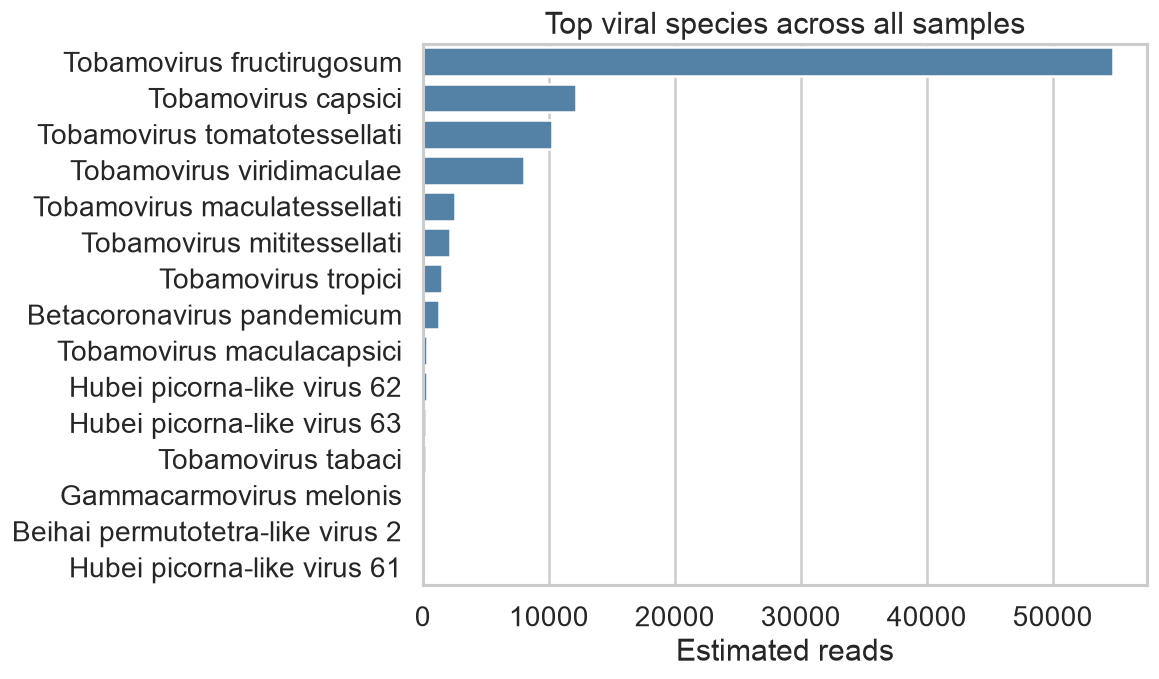

In [37]:
# Top viral taxa overall
overall_top = (
    viral.groupby("name", as_index=False)["reads"]
    .sum()
    .sort_values("reads", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=overall_top,
    y="name",
    x="reads",
    color="steelblue"
)
plt.title("Top viral species across all samples")
plt.xlabel("Estimated reads")
plt.ylabel("")
plt.tight_layout()
plt.show()

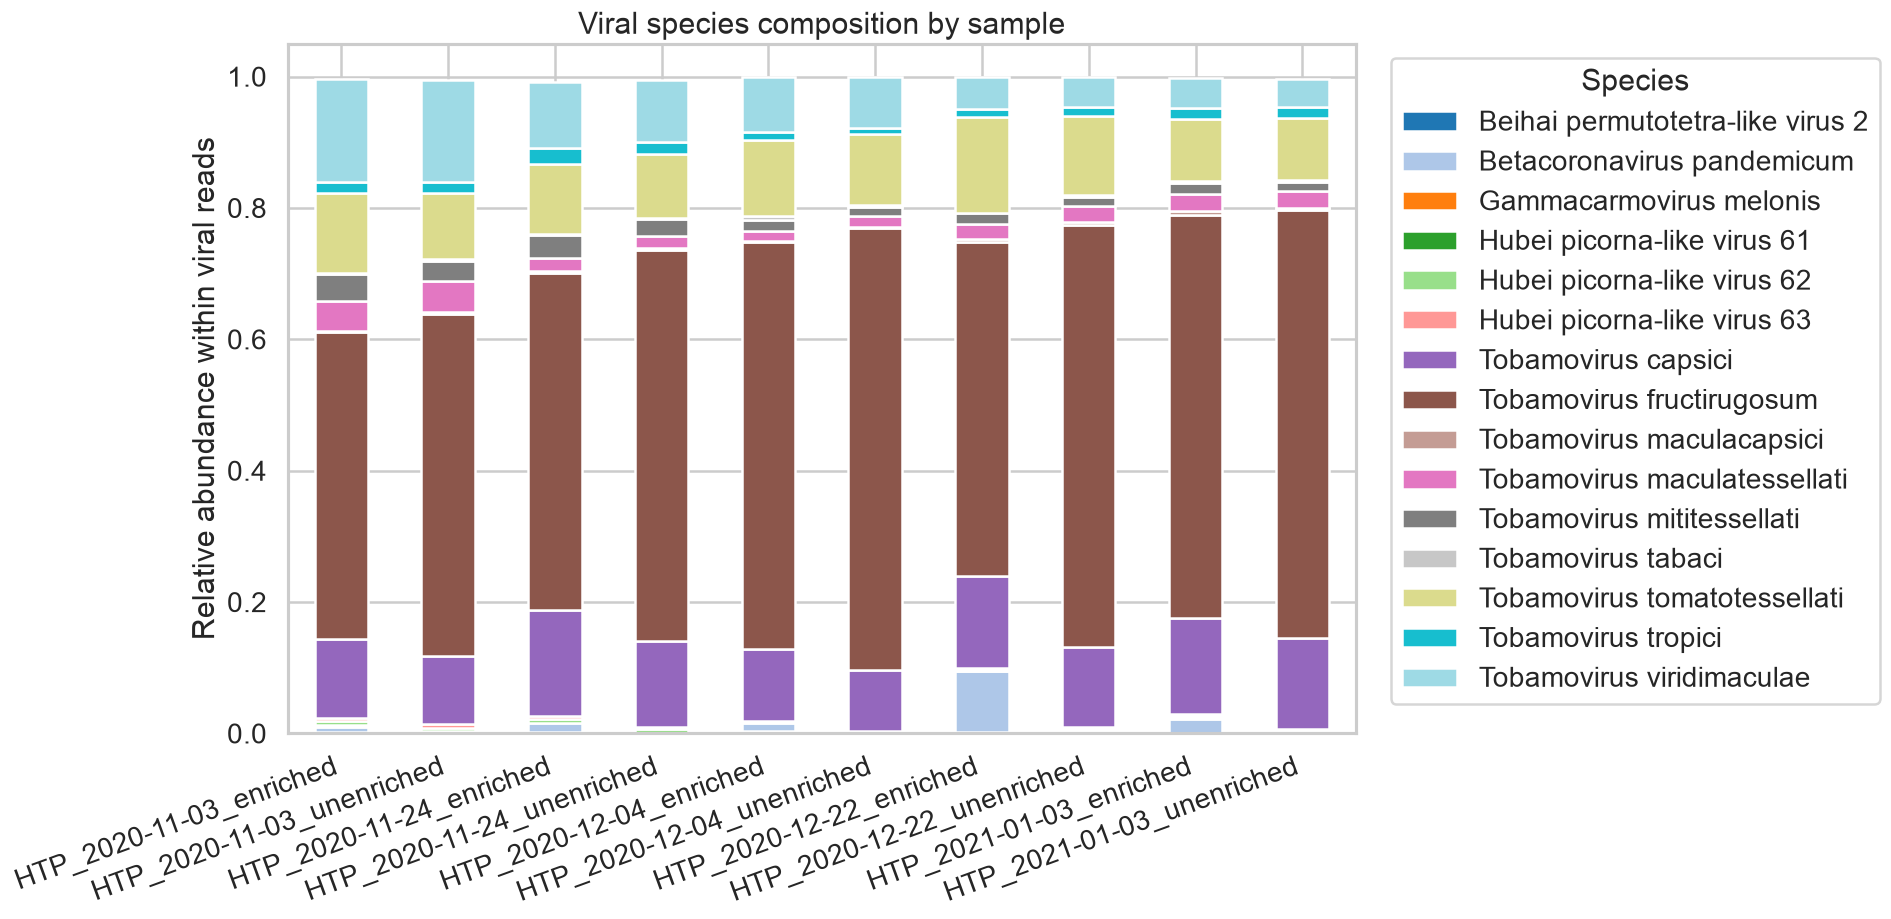

In [41]:
# Stacked composition by sample
top_taxa = overall_top["name"].tolist()

viral_top = viral[viral["name"].isin(top_taxa)].copy()

pivot_top = viral_top.pivot_table(
    index="sample",
    columns="name",
    values="relative_abundance",
    aggfunc="sum",
    fill_value=0
)

sample_order = meta.sort_values(["date", "treatment"])["sample"].tolist()
pivot_top = pivot_top.reindex(sample_order)

pivot_top.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 8),
    colormap="tab20"
)
plt.ylabel("Relative abundance within viral reads")
plt.xlabel("")
plt.title("Viral species composition by sample")
plt.xticks(rotation=20, ha="right")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Species"
)
plt.tight_layout()
plt.show()

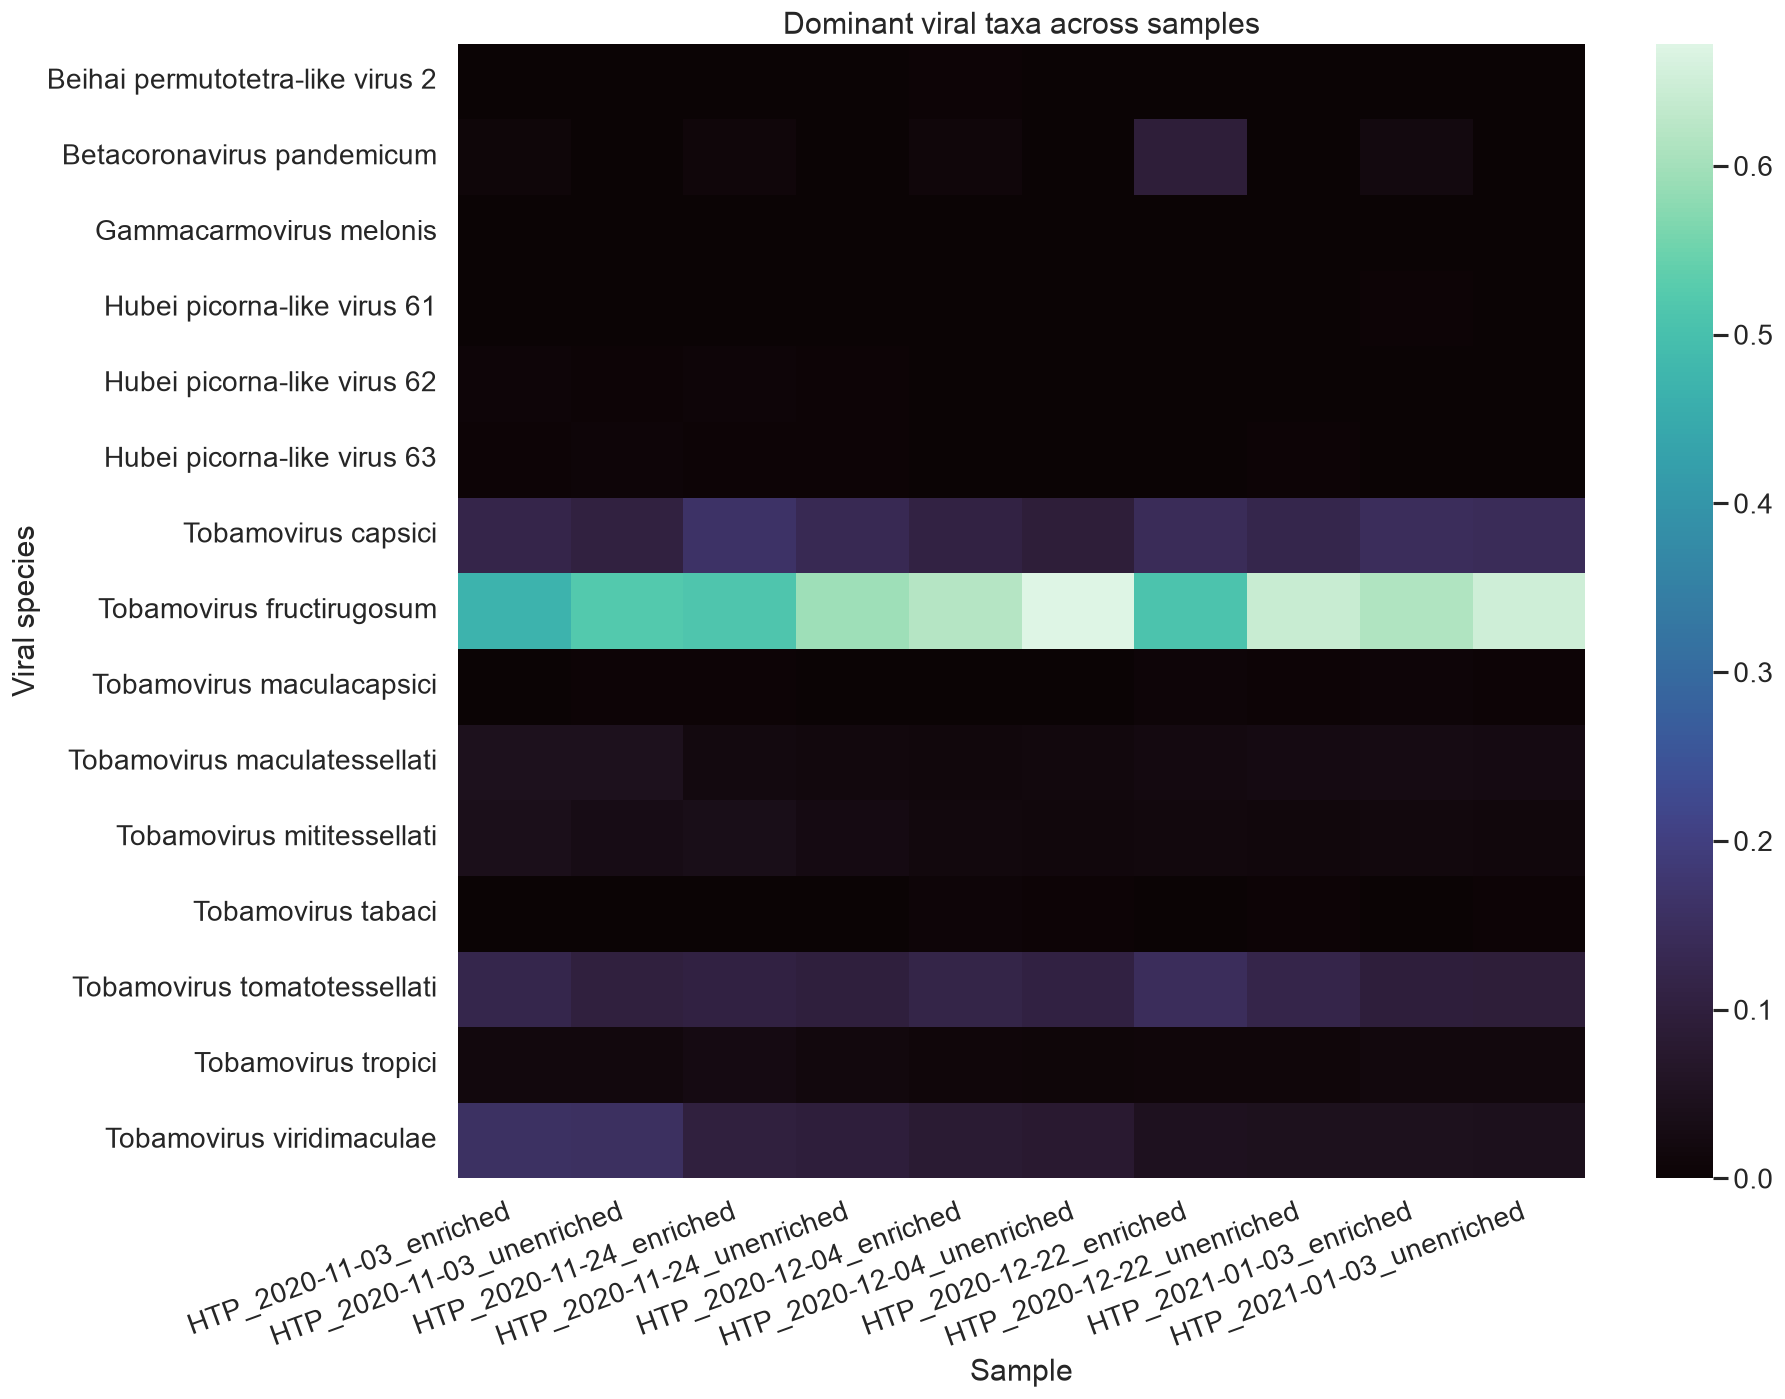

In [43]:
# Viral Heatmap
heat = viral_top.pivot_table(
    index="name",
    columns="sample",
    values="relative_abundance",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(16, 12))
sns.heatmap(heat, cmap="mako")
plt.title("Dominant viral taxa across samples")
plt.xlabel("Sample")
plt.xticks(rotation=20, ha="right")
plt.ylabel("Viral species")
plt.tight_layout()
plt.show()

> These plots identify the dominant viral taxa recovered across the selected samples and test whether enrichment changes the balance of taxa detected in wastewater. The most important comparison is whether enriched libraries preferentially recover particular viral groups relative to matched unenriched libraries collected on the same date.

### Viral Taxonomy MCQ

__If enriched and unenriched libraries from the same date show different dominant viral taxa, what is the strongest interpretation?__

> A) Library treatment can shift the observed viral composition.  
> B) The wastewater plant changed between technical replicates.  
> C) Taxonomic classification is invalid.  
> D) Viral abundance is identical across treatments.

## SARS-CoV-2 abundance and SNVs

> Because the original study includes SARS-CoV-2 detection and wastewater SNV analysis, this section isolates SARS-CoV-2-related signal from the broader virome. If the recovered signal is strong enough, it can motivate downstream alignment-based SNV analysis outside or alongside this notebook.

In [47]:
sars = viral[
    viral["name"].str.contains(
        "betacoronavirus pandemicum|sars|severe acute respiratory syndrome|corona",
        case=False,
        na=False
    )
].copy()

display(sars[["sample", "date", "treatment", "name", "reads", "relative_abundance"]]
        .sort_values(["date", "treatment", "reads"], ascending=[True, True, False]))

,sample,date,treatment,name,reads,relative_abundance
7,HTP_2020-11-03_enriched,2020-11-03,enriched,Betacoronavirus pandemicum,80.0,0.007893
40,HTP_2020-11-03_unenriched,2020-11-03,unenriched,Betacoronavirus pandemicum,0.0,0.000000
53,HTP_2020-11-24_enriched,2020-11-24,enriched,Betacoronavirus pandemicum,115.0,0.013005
86,HTP_2020-11-24_unenriched,2020-11-24,unenriched,Betacoronavirus pandemicum,0.0,0.000000
99,HTP_2020-12-04_enriched,2020-12-04,enriched,Betacoronavirus pandemicum,76.0,0.010912
130,HTP_2020-12-04_unenriched,2020-12-04,unenriched,Betacoronavirus pandemicum,0.0,0.000000
141,HTP_2020-12-22_enriched,2020-12-22,enriched,Betacoronavirus pandemicum,748.0,0.091926
177,HTP_2020-12-22_unenriched,2020-12-22,unenriched,Betacoronavirus pandemicum,0.0,0.000000
189,HTP_2021-01-03_enriched,2021-01-03,enriched,Betacoronavirus pandemicum,290.0,0.020794
225,HTP_2021-01-03_unenriched,2021-01-03,unenriched,Betacoronavirus pandemicum,0.0,0.000000


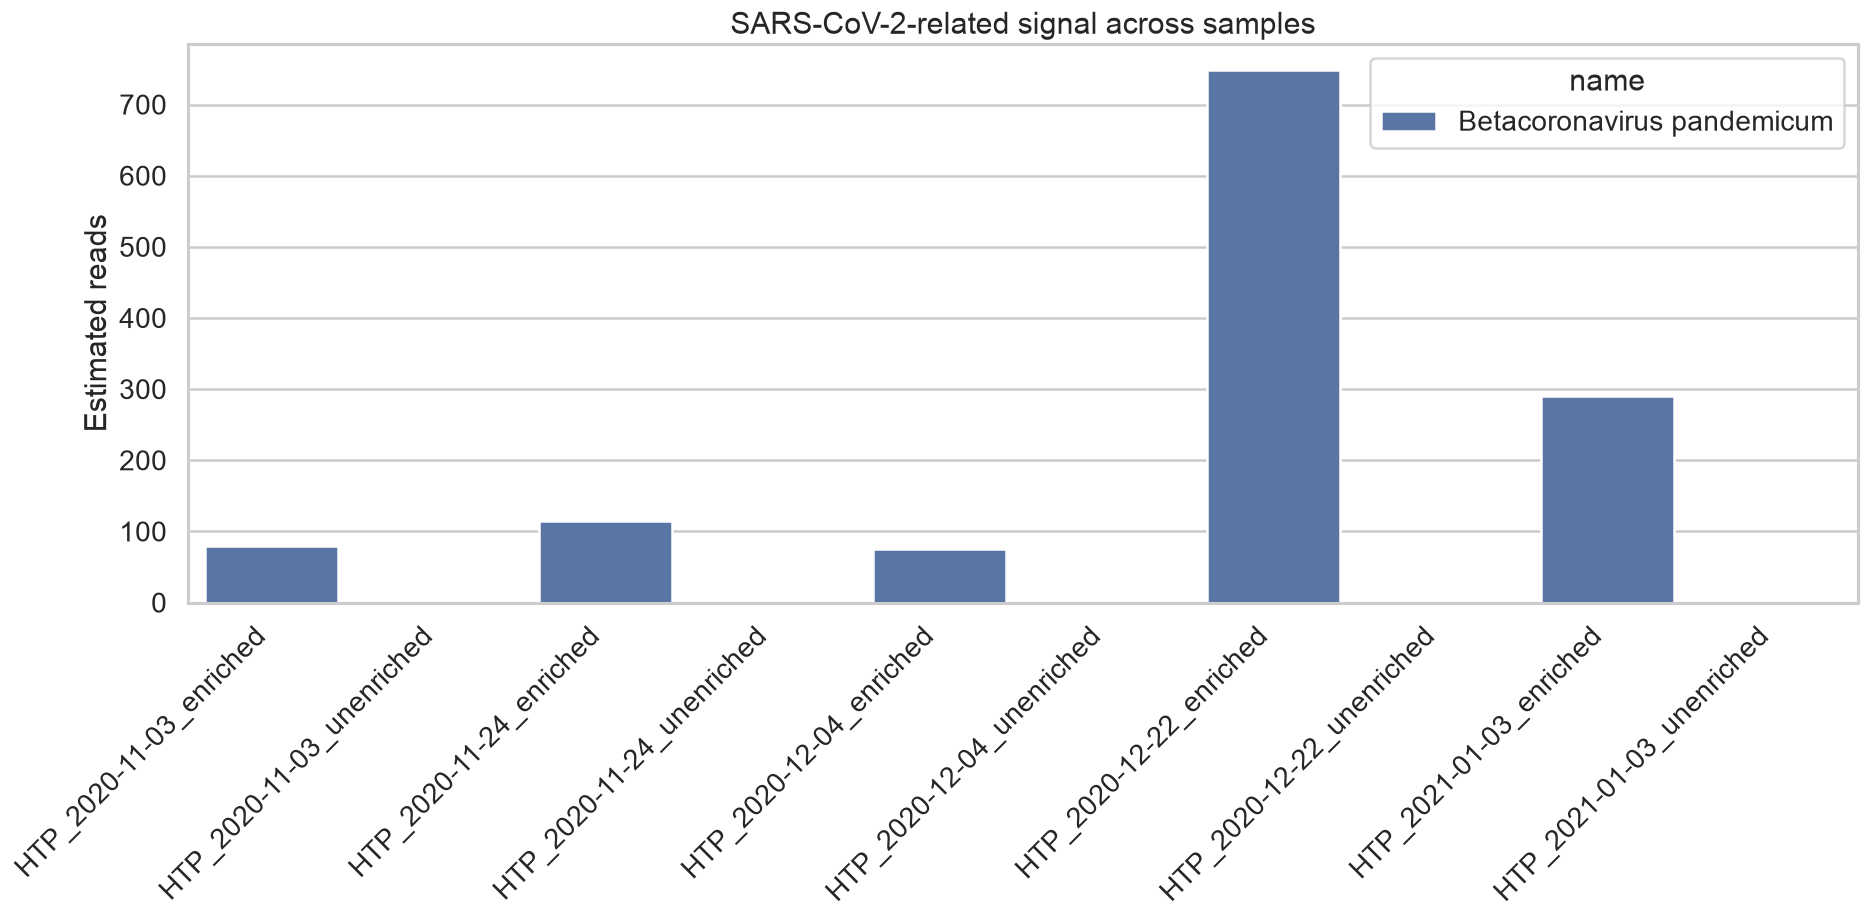

In [49]:
# SARS-CoV-2-like abundance plot
if not sars.empty:
    plt.figure(figsize=(16, 8))
    sns.barplot(
        data=sars.sort_values(["date", "sample"]),
        x="sample",
        y="reads",
        hue="name"
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Estimated reads")
    plt.xlabel("")
    plt.title("SARS-CoV-2-related signal across samples")
    plt.tight_layout()
    plt.show()
else:
    print("No SARS-CoV-2-related taxa found in viral_taxa_summary.tsv")

> The only coronavirus-related taxonomic signal recovered in these data was low-abundance assignment to **Betacoronavirus pandemicum**, a current NCBI species name associated with the SARS-related coronavirus lineage. Because this signal was sparse, these samples did not provide a strong basis for dedicated SARS-CoV-2 SNV analysis.

### SARS section MCQ

__Why is it useful to analyze SARS-CoV-2 separately from the broader wastewater virome?__

> A) It allows focused interpretation of a pathogen of specific epidemiologic interest.  
> B) It eliminates the need for taxonomic profiling.  
> C) It guarantees enough coverage for SNV analysis in every sample.  
> D) It replaces host filtering.

## Reproducibility

> All preprocessing and summary-table generation were performed with Snakemake. This notebook reads workflow outputs from `results/summary/` and `results/taxonomy/merged/`, making it executable both interactively in JupyterLab and non-interactively through the downstream Snakemake report-render rule.